
## Introduction
This project aims to build a predictive model to determine which customers are likely to subscribe to a term deposit based on a dataset of previous marketing campaigns conducted by a Portuguese bank. The dataset contains various customer demographic information, historical interactions with the bank, and external economic factors, providing a rich source of features for prediction.
Through this predictive modeling approach, the bank can focus its efforts on the most promising leads, optimizing resources and enhancing the overall success of its marketing campaigns.

## Task 1:-Prepare a complete data analysis report on the given data.

## Domain Analysis

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [5]:
!pip install prettytable

In [6]:
from prettytable import PrettyTable

In [3]:
bank = pd.read_csv('bank-additional-full.csv', delimiter=';')
bank.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
bank.shape

(41188, 21)

In [5]:
bank

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [6]:
bank.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [7]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [8]:
bank.nunique()

age                 78
job                 12
marital              4
education            8
default              3
housing              3
loan                 3
contact              2
month               10
day_of_week          5
duration          1544
campaign            42
pdays               27
previous             8
poutcome             3
emp.var.rate        10
cons.price.idx      26
cons.conf.idx       26
euribor3m          316
nr.employed         11
y                    2
dtype: int64

In [9]:
bank.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [10]:
bank.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [11]:
bank[bank.duplicated()].head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no


In [12]:
bank.drop_duplicates(keep='first',inplace=True)  ## Removed the duplicates
bank.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [13]:
scoring = 'accuracy'
bank['y'].value_counts(normalize=True)

y
no     0.887337
yes    0.112663
Name: proportion, dtype: float64

In [14]:
dtypes = pd.DataFrame(bank.dtypes.rename('type')).reset_index().astype('str')

In [15]:
dtypes = dtypes.query('index != "duration"')
numeric = dtypes[(dtypes.type.isin(['int64', 'float64'])) & (dtypes['index'] != 'duration')]['index'].values
categorical = dtypes[~(dtypes['index'].isin(numeric)) & (dtypes['index'] != 'y')]['index'].values

print('Numeric:\n', numeric)
print('Categorical:\n', categorical)

Numeric:
 ['age' 'campaign' 'pdays' 'previous' 'emp.var.rate' 'cons.price.idx'
 'cons.conf.idx' 'euribor3m' 'nr.employed']
Categorical:
 ['job' 'marital' 'education' 'default' 'housing' 'loan' 'contact' 'month'
 'day_of_week' 'poutcome']



                                                            ** Domain Analysis **

1) Age:- Represents the age of the client.
     * Analysis: Older clients might show different financial behaviors compared to younger clients, influencing the likelihood of term deposit                           subscriptions. Certain age groups could have a higher propensity for saving or investing.
     * Business Insights: Age-based segmentation can help in targeting campaigns more effectively.
2) Job:- The type of job the client has.
     * Analysis: Different occupations might have varied income levels, influencing their financial decisions. For example, clients in higher-income                      professions (e.g., management, executive roles) may be more likely to subscribe to term deposits.
     * Business Insights: Analyzing job categories can reveal which professional groups are more inclined to invest, helping to target financial                                   products better.
3) Marital:- The marital status of the client (single, married, divorced).
     * Analysis: Married clients might have different financial goals compared to single or divorced clients, possibly being more conservative with                       their savings and investment.
     * Business Insights: This can help personalize marketing strategies, as marital status could influence a person’s savings goals (e.g., for family                             or retirement).
4) Education:- The level of education attained by the client.
     * Analysis: Clients with higher education levels may have better financial literacy, leading them to be more interested in financial products such                   as term deposits.
     * Business Insights: Financial literacy campaigns or premium financial products could be tailored for clients with higher educational backgrounds.
5) Default:- Indicates whether the client has credit in default (yes, no, or unknown).
     * Analysis: Clients with a history of default may pose higher risks, affecting the bank’s decision on offering certain financial products. Those                     without defaults are more likely to engage in long-term savings like term deposits.
     * Business Insights: This feature can be used to assess the risk profile of clients and tailor products accordingly.
6) Housing:- Whether the client has a housing loan (yes or no).
     * Analysis: Clients with housing loans may have less liquidity to invest in other financial products. Alternatively, they may be looking for                         additional savings mechanisms to offset the loan burden.
     * Business Insights: Banks can offer bundled products (such as mortgage and savings packages) to clients with housing loans.
7) Loan:- Whether the client has a personal loan (yes or no).
     * Analysis: Similar to housing loans, clients with personal loans may be less inclined to invest in term deposits due to financial obligations.
     * Business Insights: This can help identify clients who may benefit from refinancing options or loan consolidation services.
8) Contact:- The type of communication contact (telephone or cellular).
     * Analysis: Different contact methods may have varying success rates. For instance, cellular calls may be more effective than telephone calls due                    to ease of access.
     * Business Insights: Helps determine which communication method is more successful in engaging clients and driving term deposit subscriptions.
9) Month:- The last contact month of the year.
     * Analysis: Subscription rates might vary across months, with certain months being busier for banking activity (e.g., post-bonus periods or year-                    end planning).
     * Business Insights: Banks can launch specific campaigns during months that historically show high client engagement.
10) Day_of_Week:- The day of the week when the client was last contacted.
     * Analysis: Response rates may vary depending on the day of the week. For instance, mid-week contacts might perform better than weekend or Monday                    calls.
     * Business Insights: Helps optimize the timing of campaigns to improve response and conversion rates.
11) Duration:- The duration of the last contact in seconds.
     * Analysis: Longer call durations might indicate higher interest from the client, while shorter calls might signal disinterest. However, this                        field should be carefully interpreted, as longer calls don’t always guarantee success.
     * Business Insights: Duration can be used as a quality measure for sales calls, helping banks improve call scripts and customer engagement tactics.
12) Campaign:- The number of contacts performed during this campaign.
     * Analysis: A higher number of contacts could indicate persistent outreach but may also lead to diminishing returns if clients become annoyed with                   too many follow-ups.
    * Business Insights: Helps in balancing persistence with customer satisfaction. Optimal contact frequency can improve the likelihood of                                       subscription without overwhelming the client.
13) Pdays:- Number of days since the client was last contacted in a previous campaign (999 indicates never contacted).
     * Analysis: Clients who were recently contacted might be more familiar with the bank’s offerings, affecting their decision to subscribe.
     * Business Insights: Can be used to avoid over-contacting clients, reducing the risk of spamming, while ensuring that follow-up is timely and                                 relevant.
14) Previous:- The number of contacts performed before this campaign.
     * Analysis: This indicates the bank's previous interaction with the client. Frequent contacts without results might suggest client disinterest.
     * Business Insights: Helps identify which clients are warmer leads based on past interactions, improving conversion rates in future campaigns.
15) Poutcome:- Outcome of the previous marketing campaign (success, failure, or nonexistent).
     * Analysis: Clients who responded positively in previous campaigns are more likely to do so again.
     * Business Insights: Success in previous campaigns can be used to segment and target clients more effectively in future campaigns.
16) Emp.Var.Rate:- Employment variation rate (indicator of economic conditions).
     * Analysis: A higher employment variation rate may indicate favorable economic conditions, which could increase the likelihood of clients                            investing in term deposits.
     * Business Insights: Helps in understanding the economic context in which the campaign is conducted, allowing for better timing of financial                                  product offerings.
17) Cons.Price.Idx:- Consumer price index (CPI) indicating inflation levels.
     * Analysis: Higher inflation might lower client savings as their purchasing power diminishes, impacting the decision to invest in a term deposit.
     * Business Insights: CPI data can be useful in positioning financial products during times of inflation, such as offering inflation-protected                                 products.
18) Cons.Conf.Idx:- Consumer confidence index indicating economic sentiment.
     * Analysis: Lower consumer confidence might discourage people from investing, while higher confidence could correlate with increased term deposit                    subscriptions.
     * Business Insights: Helps in understanding consumer sentiment and adjusting marketing strategies based on whether clients feel financially secure.
19) Euribor3m:- The Euribor 3-month rate (a key European interest rate).
     * Analysis: A higher Euribor rate might make saving more attractive as interest rates on deposits increase, influencing client behavior.
     * Business Insights: Interest rates can guide the bank's product pricing strategies, making it important to offer competitive rates on savings and                            deposits.
20) Nr.Employed:- Number of employees in the economy.
     * Analysis: Higher employment numbers generally indicate a healthy economy, which could positively influence savings and investment decisions.
     * Business Insights: Employment levels can help predict client behavior, allowing banks to adjust their product offerings based on economic                                   conditions.
21) Y (Target Variable):- Whether the client subscribed to a term deposit (yes or no).
     * Analysis: This is the target variable, representing the success or failure of the bank’s marketing campaign.
     * Business Insights: Understanding the factors that lead to successful term deposit subscriptions is crucial for optimizing future campaigns and                              improving product targeting.



## Exploratory Data Analysis

In [16]:
bank_client = bank.iloc[: , 0:7]
bank_client.head()

,age,job,marital,education,default,housing,loan
0,56,housemaid,married,basic.4y,no,no,no
1,57,services,married,high.school,unknown,no,no
2,37,services,married,high.school,no,yes,no
3,40,admin.,married,basic.6y,no,no,no
4,56,services,married,high.school,no,no,yes


In [17]:
print('Jobs:\n', bank_client['job'].unique())

Jobs:
 ['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']


In [18]:
print('marital:\n', bank_client['marital'].unique())

marital:
 ['married' 'single' 'divorced' 'unknown']


In [19]:
print('education:\n', bank_client['education'].unique())

education:
 ['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']


In [20]:
print('default:\n', bank_client['default'].unique())

default:
 ['no' 'unknown' 'yes']


In [21]:
print('housing:\n', bank_client['housing'].unique())

housing:
 ['no' 'yes' 'unknown']


In [22]:
print('loan:\n', bank_client['loan'].unique())

loan:
 ['no' 'yes' 'unknown']


In [23]:
print('Min age: ', bank_client['age'].max())
print('Max age: ', bank_client['age'].min())
print('Null Values: ', bank_client['age'].isnull().any())

Min age:  98
Max age:  17
Null Values:  False


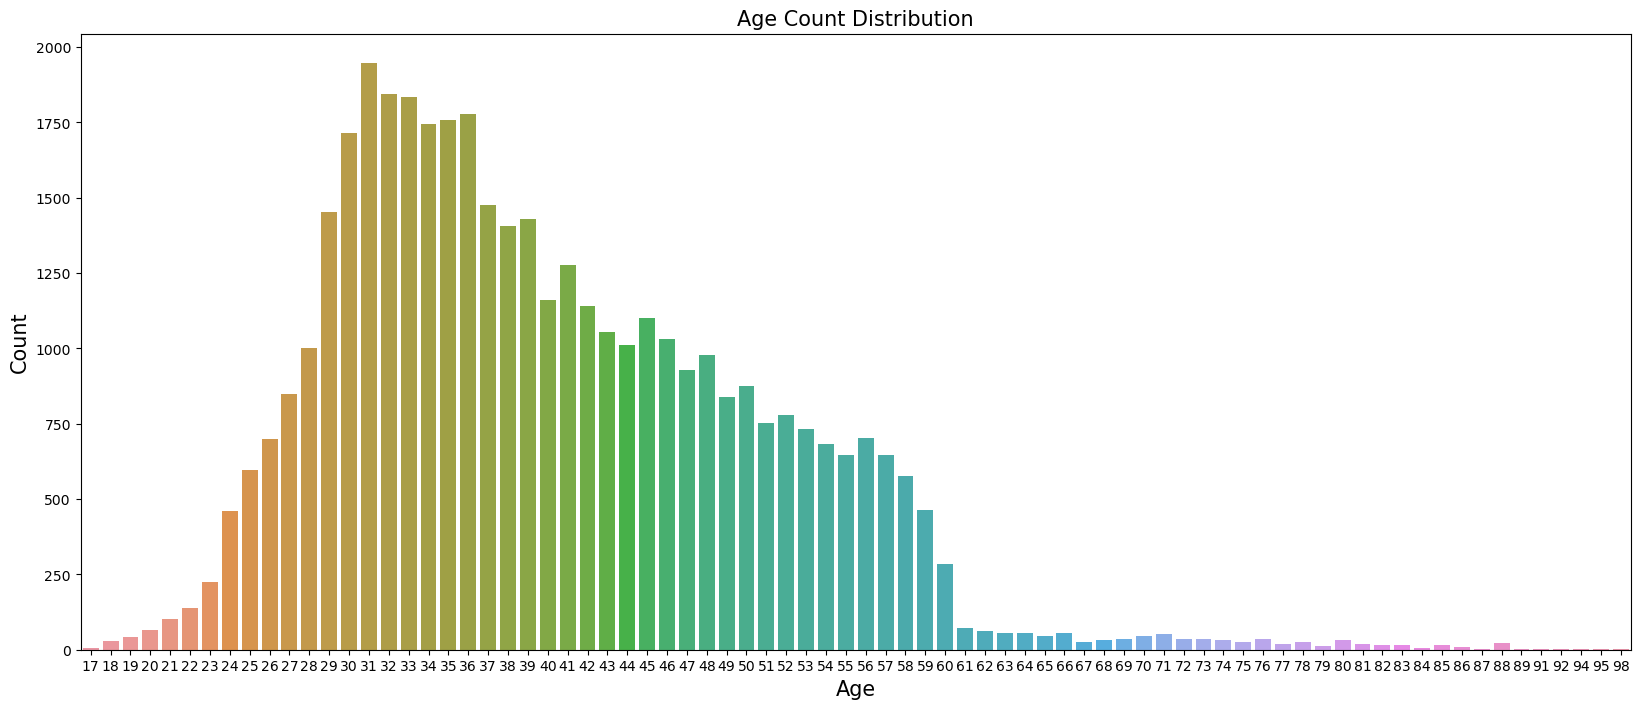

In [24]:
plt.figure(figsize=(20, 8))
sns.countplot(x = 'age', data = bank_client)
plt.xlabel('Age', fontsize=15)
plt.ylabel('Count', fontsize=15)
plt.title('Age Count Distribution', fontsize=15)
plt.show()

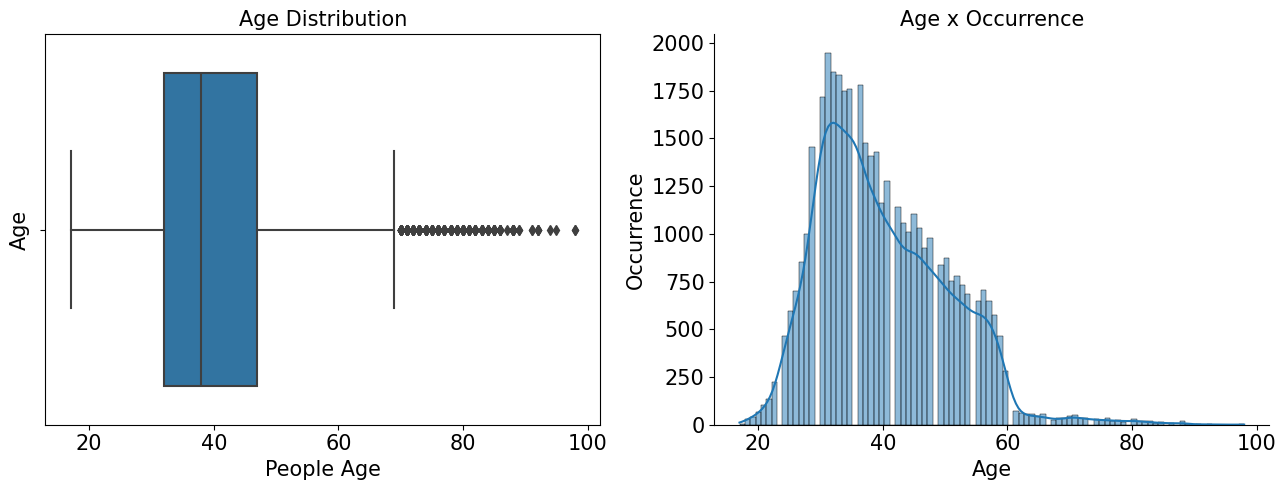

In [25]:

# Assuming 'bank_client' is the dataframe containing the data
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(13, 5))

# Boxplot for age
sns.boxplot(x='age', data=bank_client, orient='v', ax=ax1)
ax1.set_xlabel('People Age', fontsize=15)
ax1.set_ylabel('Age', fontsize=15)
ax1.set_title('Age Distribution', fontsize=15)
ax1.tick_params(labelsize=15)

# Distribution plot (replacing distplot with histplot)
sns.histplot(bank_client['age'], kde=True, ax=ax2)  # kde=True adds the Kernel Density Estimate line
sns.despine(ax=ax2)
ax2.set_xlabel('Age', fontsize=15)
ax2.set_ylabel('Occurrence', fontsize=15)  
ax2.set_title('Age x Occurrence', fontsize=15)
ax2.tick_params(labelsize=15)

# Adjust layout
plt.subplots_adjust(wspace=0.5)
plt.tight_layout()

# Show the plots
plt.show()


In [26]:
Q1=bank_client["age"].quantile(0.25)
print("lower quartile",Q1)
Q3=bank_client["age"].quantile(0.75)
print("upper quartile",Q3)

lower quartile 32.0
upper quartile 47.0


In [27]:
IQR=Q3-Q1
IQR

15.0

In [28]:
lower_limit=Q1-1.5*IQR
print("lower_limit is",lower_limit)
upper_limit=Q3+1.5*IQR
print("upper_limit is",upper_limit)

lower_limit is 9.5
upper_limit is 69.5


In [29]:
bank_client.loc[bank_client['age']>upper_limit]

,age,job,marital,education,default,housing,loan
27713,70,retired,divorced,basic.4y,no,yes,no
27757,76,retired,married,university.degree,no,no,yes
27780,73,retired,married,university.degree,no,yes,no
27800,88,retired,divorced,basic.4y,no,yes,no
27802,88,retired,divorced,basic.4y,no,no,no
...,...,...,...,...,...,...,...
40986,84,retired,divorced,basic.4y,unknown,yes,yes
40996,81,retired,married,basic.4y,no,yes,no
41004,80,retired,married,professional.course,no,yes,no
41183,73,retired,married,professional.course,no,yes,no


In [30]:
print('Numerber of outliers: ', bank_client[bank_client['age'] > 69.6]['age'].count())
print('Number of clients: ', len(bank_client))
print('Outliers are:', round(bank_client[bank_client['age'] > 69.6]['age'].count()*100/len(bank_client),2), '%')

Numerber of outliers:  468
Number of clients:  41176
Outliers are: 1.14 %


In [31]:
# Calculating statistical values for the 'age' column
print('MEAN:', round(bank_client['age'].mean(), 1))

# A low standard deviation indicates that the data points tend to be close to the mean or expected value
# A high standard deviation indicates that the data points are scattered
print('STD :', round(bank_client['age'].std(), 1))

# Coefficient of Variation (CV): (STD / MEAN) * 100
# CV < 15% -> Low dispersion, CV > 30% -> High dispersion
cv = round((bank_client['age'].std() * 100 / bank_client['age'].mean()), 1)
print('CV  :', cv, '- High middle dispersion' if cv > 30 else '- Low middle dispersion')


MEAN: 40.0
STD : 10.4
CV  : 26.0 - Low middle dispersion


Due to Low middle dispersion and just looking at the graph we cannot conclude if age have a high effect to our variable y.Low middle dispersion means we have people with all ages and maybe all of them can subscript a term deposit, or not. The outliers was calculated, so we go with fitting the model with and without them

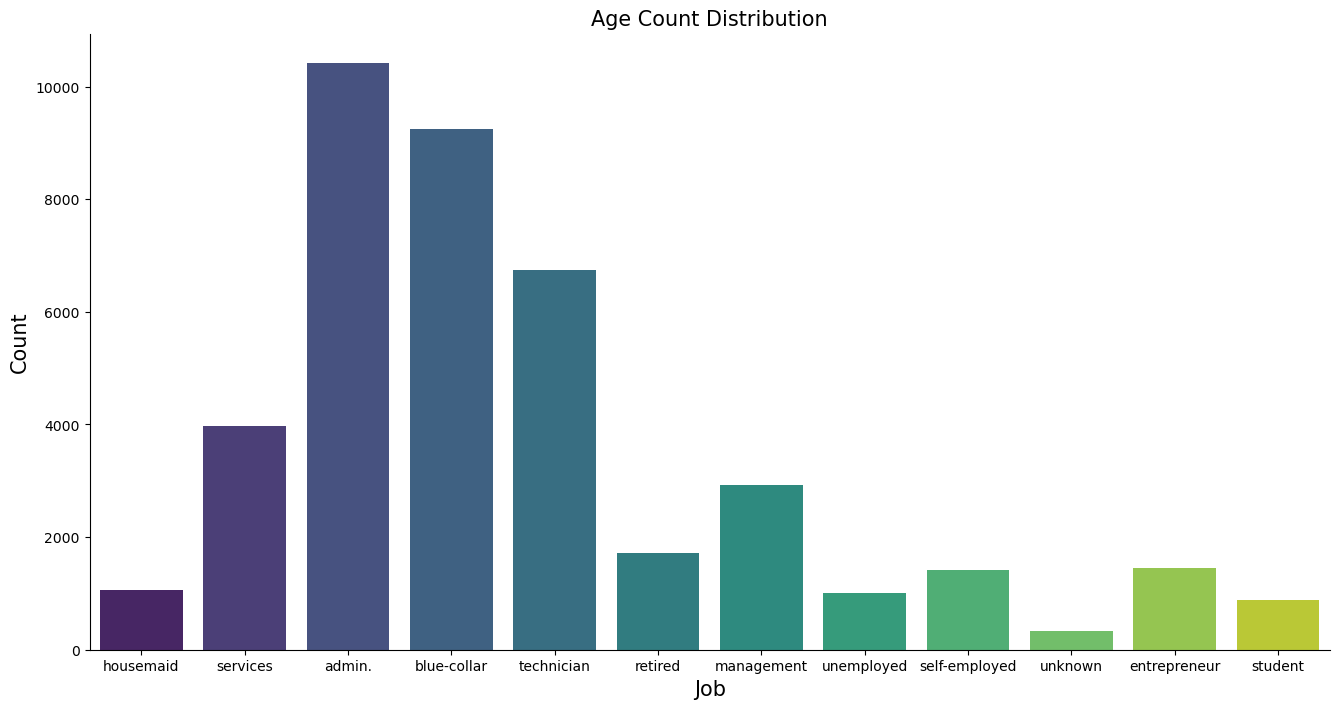

In [32]:
plt.figure(figsize=(16,8))
sns.countplot(x='job', data=bank_client, palette='viridis')
plt.xlabel('Job', fontsize=15)
plt.ylabel('Count', fontsize=15)
plt.title('Age Count Distribution', fontsize=15)
sns.despine()

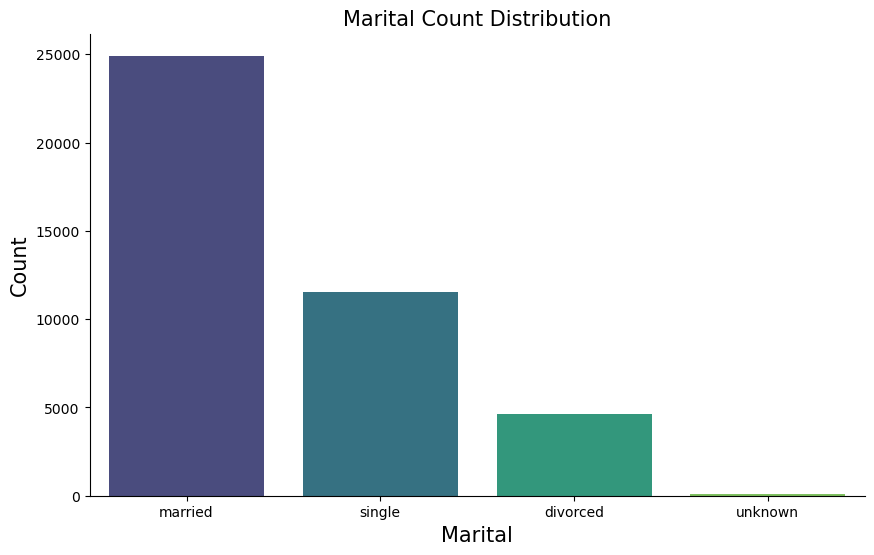

In [33]:
plt.figure(figsize=(10,6))
sns.countplot(x='marital', data=bank_client, palette='viridis')
plt.xlabel('Marital', fontsize=15)
plt.ylabel('Count', fontsize=15)
plt.title('Marital Count Distribution', fontsize=15)
sns.despine()

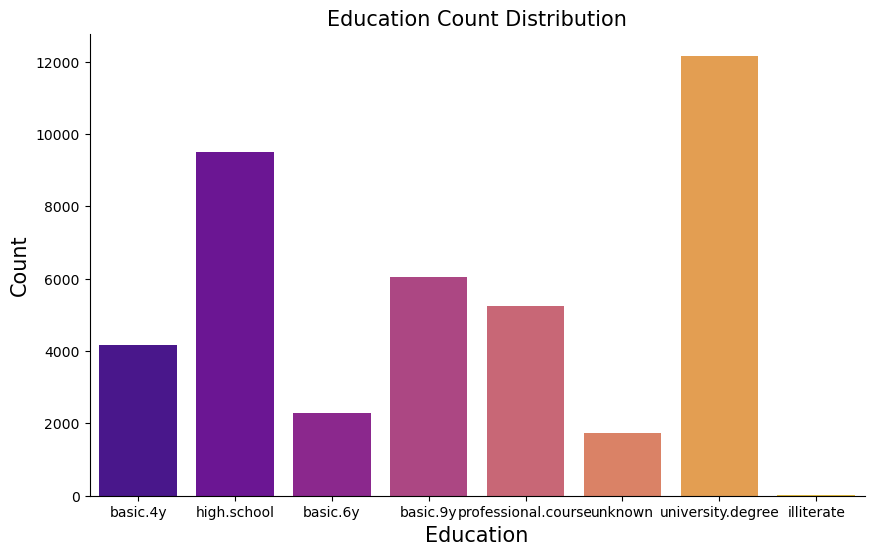

In [34]:
plt.figure(figsize=(10,6))
sns.countplot(x='education', data=bank_client, palette='plasma')
plt.xlabel('Education', fontsize=15)
plt.ylabel('Count', fontsize=15)
plt.title('Education Count Distribution', fontsize=15)
sns.despine()
plt.show()

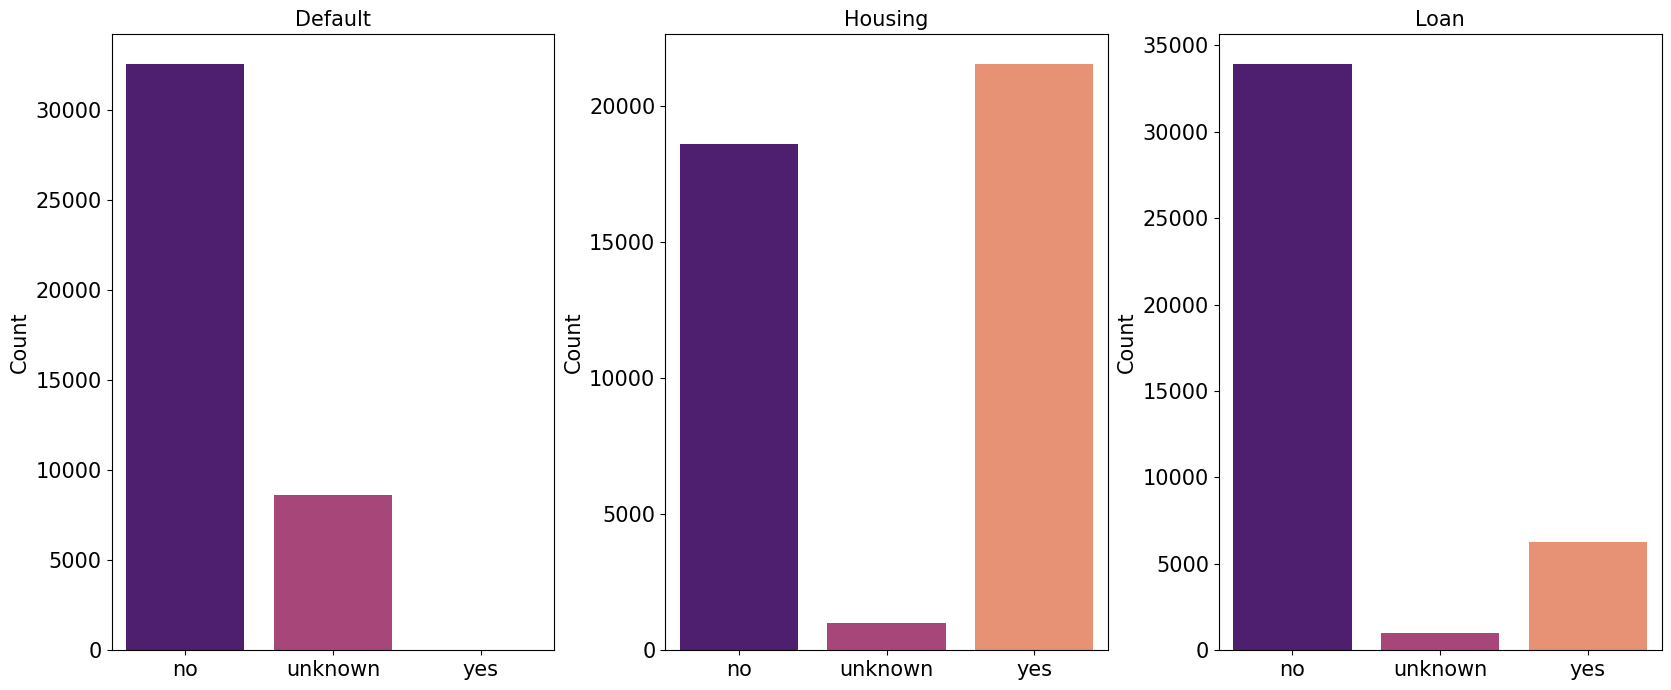

In [35]:
# Default, has credit in default ?
fig, (ax1, ax2, ax3) = plt.subplots(nrows = 1, ncols = 3, figsize = (20,8))
sns.countplot(x = 'default', data = bank_client, ax = ax1, order = ['no', 'unknown', 'yes'], palette='magma')
ax1.set_title('Default', fontsize=15)
ax1.set_xlabel('')
ax1.set_ylabel('Count', fontsize=15)
ax1.tick_params(labelsize=15)

# Housing, has housing loan ?
sns.countplot(x = 'housing', data = bank_client, ax = ax2, order = ['no', 'unknown', 'yes'], palette='magma')
ax2.set_title('Housing', fontsize=15)
ax2.set_xlabel('')
ax2.set_ylabel('Count', fontsize=15)
ax2.tick_params(labelsize=15)

# Loan, has personal loan ?
sns.countplot(x = 'loan', data = bank_client, ax = ax3, order = ['no', 'unknown', 'yes'], palette='magma')
ax3.set_title('Loan', fontsize=15)
ax3.set_xlabel('')
ax3.set_ylabel('Count', fontsize=15)
ax3.tick_params(labelsize=15)

plt.subplots_adjust(wspace=0.25)

In [36]:
print('Default:\n No credit in default:'     , bank_client[bank_client['default'] == 'no']     ['age'].count(),
              '\n Unknown credit in default:', bank_client[bank_client['default'] == 'unknown']['age'].count(),
              '\n Yes to credit in default:' , bank_client[bank_client['default'] == 'yes']    ['age'].count())

Default:
 No credit in default: 32577 
 Unknown credit in default: 8596 
 Yes to credit in default: 3


In [37]:
print('Housing:\n No housing in loan:'     , bank_client[bank_client['housing'] == 'no']     ['age'].count(),
              '\n Unknown housing in loan:', bank_client[bank_client['housing'] == 'unknown']['age'].count(),
              '\n Yes to housing in loan:' , bank_client[bank_client['housing'] == 'yes']    ['age'].count())

Housing:
 No housing in loan: 18615 
 Unknown housing in loan: 990 
 Yes to housing in loan: 21571


In [38]:
print('Housing:\n No to personal loan:'     , bank_client[bank_client['loan'] == 'no']     ['age'].count(),
              '\n Unknown to personal loan:', bank_client[bank_client['loan'] == 'unknown']['age'].count(),
              '\n Yes to personal loan:'    , bank_client[bank_client['loan'] == 'yes']    ['age'].count())

Housing:
 No to personal loan: 33938 
 Unknown to personal loan: 990 
 Yes to personal loan: 6248


In [39]:
from sklearn.preprocessing import LabelEncoder
labelencoder_X = LabelEncoder()
bank_client['job']      = labelencoder_X.fit_transform(bank_client['job']) 
bank_client['marital']  = labelencoder_X.fit_transform(bank_client['marital']) 
bank_client['education']= labelencoder_X.fit_transform(bank_client['education']) 
bank_client['default']  = labelencoder_X.fit_transform(bank_client['default']) 
bank_client['housing']  = labelencoder_X.fit_transform(bank_client['housing']) 
bank_client['loan']     = labelencoder_X.fit_transform(bank_client['loan']) 

In [40]:
#function to creat group of ages, this helps because we have 78 differente values here
def age(dataframe):
    dataframe.loc[dataframe['age'] <= 32, 'age'] = 1
    dataframe.loc[(dataframe['age'] > 32) & (dataframe['age'] <= 47), 'age'] = 2
    dataframe.loc[(dataframe['age'] > 47) & (dataframe['age'] <= 70), 'age'] = 3
    dataframe.loc[(dataframe['age'] > 70) & (dataframe['age'] <= 98), 'age'] = 4
           
    return dataframe

age(bank_client);


In [41]:
bank_client.head()

,age,job,marital,education,default,housing,loan
0,3,3,1,0,0,0,0
1,3,7,1,3,1,0,0
2,2,7,1,3,0,2,0
3,2,0,1,1,0,0,0
4,3,7,1,3,0,0,2


In [42]:
bank_client.shape

(41176, 7)

In [43]:
bank_related = bank.iloc[: , 7:11]
bank_related.head()

,contact,month,day_of_week,duration
0,telephone,may,mon,261
1,telephone,may,mon,149
2,telephone,may,mon,226
3,telephone,may,mon,151
4,telephone,may,mon,307


In [44]:
bank_related.isnull().sum()

contact        0
month          0
day_of_week    0
duration       0
dtype: int64

In [45]:
print("Kind of Contact: \n", bank_related['contact'].unique())

Kind of Contact: 
 ['telephone' 'cellular']


In [46]:
print("\nWhich monthis this campaing work: \n", bank_related['month'].unique())


Which monthis this campaing work: 
 ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']


In [47]:
print("\nWhich days of week this campaing work: \n", bank_related['day_of_week'].unique())


Which days of week this campaing work: 
 ['mon' 'tue' 'wed' 'thu' 'fri']


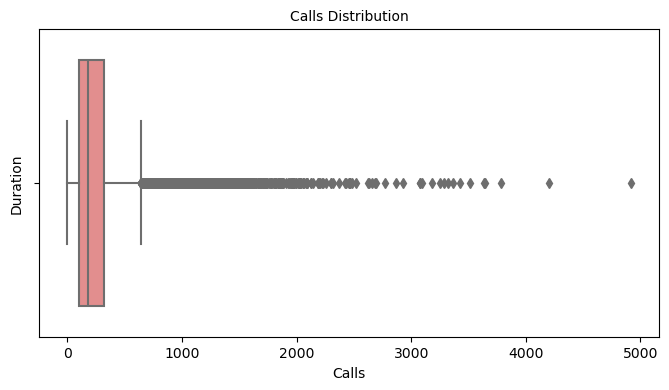

In [48]:
plt.figure(figsize=(8,4))
sns.boxplot(x='duration', data=bank_related, orient='v', color='lightcoral')
plt.xlabel('Calls', fontsize=10)
plt.ylabel('Duration', fontsize=10)
plt.title('Calls Distribution', fontsize=10)
plt.show()

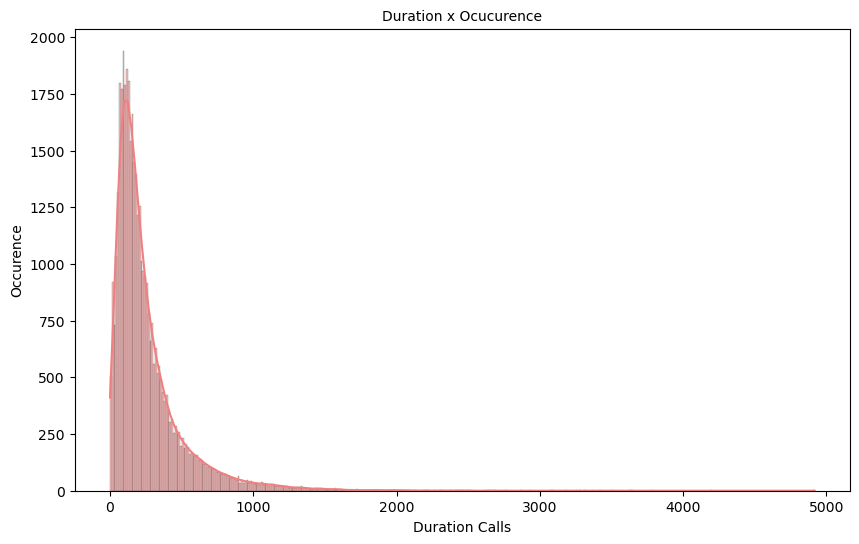

In [49]:
plt.figure(figsize=(10,6))
sns.histplot(bank_related['duration'],kde=True, color='lightcoral')
plt.xlabel('Duration Calls', fontsize=10)
plt.ylabel('Occurence', fontsize=10)
plt.title('Duration x Ocucurence', fontsize=10)
plt.show()

In [50]:
print("Max duration  call in minutes:  ", round((bank_related['duration'].max()/60),1))
print("Min duration  call in minutes:   ", round((bank_related['duration'].min()/60),1))
print("Mean duration call in minutes:   ", round((bank_related['duration'].mean()/60),1))
print("STD duration  call in minutes:   ", round((bank_related['duration'].std()/60),1))
# Std close to the mean means that the data values are close to the mean 

Max duration  call in minutes:   82.0
Min duration  call in minutes:    0.0
Mean duration call in minutes:    4.3
STD duration  call in minutes:    4.3


In [51]:
Q1=bank_related["duration"].quantile(0.25)
print("lower quartile",Q1)
Q3=bank_related["duration"].quantile(0.75)
print("upper quartile",Q3)

lower quartile 102.0
upper quartile 319.0


In [52]:
IQR=Q3-Q1
IQR

217.0

In [53]:
lower_limit=Q1-1.5*IQR
print("lower_limit is",lower_limit)
upper_limit=Q3+1.5*IQR
print("upper_limit is",upper_limit)

lower_limit is -223.5
upper_limit is 644.5


In [54]:
bank_related.loc[bank_related['duration']>upper_limit].count()

contact        2963
month          2963
day_of_week    2963
duration       2963
dtype: int64

In [55]:
print('Numerber of outliers: ', bank_related[bank_related['duration'] > 644.5]['duration'].count())
print('Number of clients: ', len(bank_related))
#Outliers in %
print('Outliers are:', round(bank_related[bank_related['duration'] > 644.5]['duration'].count()*100/len(bank_related),2), '%')

Numerber of outliers:  2963
Number of clients:  41176
Outliers are: 7.2 %


In [56]:
bank_related.loc[bank_related['duration']>upper_limit,"duration"]=bank_related['duration'].mean()

In [57]:
bank_related.loc[bank_related['duration']>upper_limit].count()

contact        0
month          0
day_of_week    0
duration       0
dtype: int64

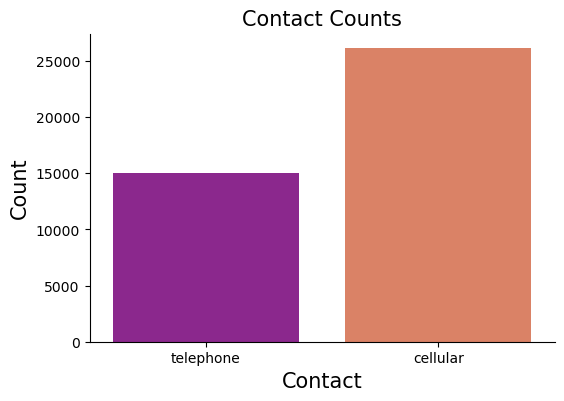

In [58]:
plt.figure(figsize=(6,4))
sns.countplot(x='contact', data=bank_related, palette='plasma')
plt.xlabel('Contact', fontsize=15)
plt.ylabel('Count', fontsize=15)
plt.title('Contact Counts', fontsize=15)
sns.despine()
plt.show()

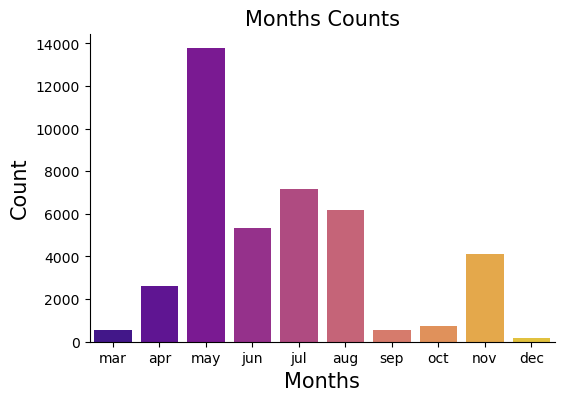

In [59]:
plt.figure(figsize=(6,4))
sns.countplot(x='month', data=bank_related,order = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'], palette='plasma')
plt.xlabel('Months', fontsize=15)
plt.ylabel('Count', fontsize=15)
plt.title('Months Counts', fontsize=15)
sns.despine()
plt.show()

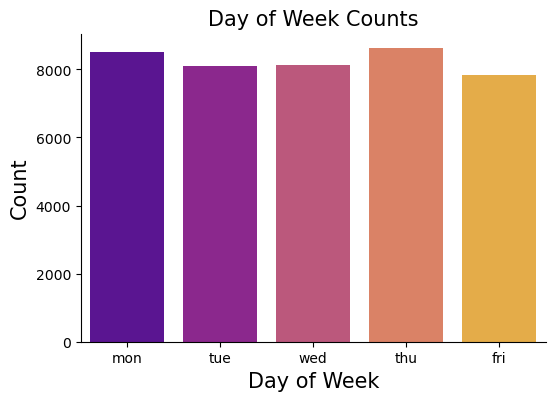

In [60]:
plt.figure(figsize=(6,4))
sns.countplot(x='day_of_week', data=bank_related, palette='plasma')
plt.xlabel('Day of Week', fontsize=15)
plt.ylabel('Count', fontsize=15)
plt.title('Day of Week Counts', fontsize=15)
sns.despine()
plt.show()

In [61]:
from sklearn.preprocessing import LabelEncoder
labelencoder_X = LabelEncoder()
bank_related['contact']     = labelencoder_X.fit_transform(bank_related['contact']) 
bank_related['month']       = labelencoder_X.fit_transform(bank_related['month']) 
bank_related['day_of_week'] = labelencoder_X.fit_transform(bank_related['day_of_week']) 

In [62]:
bank_related.head()

,contact,month,day_of_week,duration
0,1,6,1,261.0
1,1,6,1,149.0
2,1,6,1,226.0
3,1,6,1,151.0
4,1,6,1,307.0


In [63]:
def duration(data):

    data.loc[data['duration'] <= 102, 'duration'] = 1
    data.loc[(data['duration'] > 102) & (data['duration'] <= 180)  , 'duration']   = 2
    data.loc[(data['duration'] > 180) & (data['duration'] <= 319)  , 'duration']   = 3
    data.loc[(data['duration'] > 319) & (data['duration'] <= 644.5), 'duration']   = 4
    data.loc[data['duration']  > 644.5, 'duration'] = 5

    return data
duration(bank_related);

In [64]:
bank_related.head()

,contact,month,day_of_week,duration
0,1,6,1,3.0
1,1,6,1,2.0
2,1,6,1,3.0
3,1,6,1,2.0
4,1,6,1,3.0


In [65]:
bank_se = bank.loc[: , ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']]
bank_se.head()

,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,1.1,93.994,-36.4,4.857,5191.0
1,1.1,93.994,-36.4,4.857,5191.0
2,1.1,93.994,-36.4,4.857,5191.0
3,1.1,93.994,-36.4,4.857,5191.0
4,1.1,93.994,-36.4,4.857,5191.0


In [66]:
bank_o = bank.loc[: , ['campaign', 'pdays','previous', 'poutcome']]
bank_o.head()

,campaign,pdays,previous,poutcome
0,1,999,0,nonexistent
1,1,999,0,nonexistent
2,1,999,0,nonexistent
3,1,999,0,nonexistent
4,1,999,0,nonexistent


In [67]:
bank_o['poutcome'].unique()

array(['nonexistent', 'failure', 'success'], dtype=object)

In [68]:
bank_o['poutcome'].replace(['nonexistent', 'failure', 'success'], [1,2,3], inplace  = True)
bank_o.head()

,campaign,pdays,previous,poutcome
0,1,999,0,1
1,1,999,0,1
2,1,999,0,1
3,1,999,0,1
4,1,999,0,1


In [69]:
bank['y'].unique()

array(['no', 'yes'], dtype=object)

In [70]:
# Convert the target variable 'y' to 0 and 1
bank['y'] = bank['y'].map({'yes': 1, 'no': 0})

# Check the changes
bank.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


## Task 2:-Create a predictive model which will help the bank marketing team to know which customer will buy the product.

## Model Creation and Evaluation

In [71]:
bank_final= pd.concat([bank_client, bank_related, bank_se, bank_o], axis = 1)
bank_final = bank_final[['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
                     'contact', 'month', 'day_of_week', 'duration', 'emp.var.rate', 'cons.price.idx', 
                     'cons.conf.idx', 'euribor3m', 'nr.employed', 'campaign', 'pdays', 'previous', 'poutcome']]
bank_final.shape

(41176, 20)

In [72]:
x = bank_final
y = bank['y']

In [73]:
x.head(2)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,campaign,pdays,previous,poutcome
0,3,3,1,0,0,0,0,1,6,1,3.0,1.1,93.994,-36.4,4.857,5191.0,1,999,0,1
1,3,7,1,3,1,0,0,1,6,1,2.0,1.1,93.994,-36.4,4.857,5191.0,1,999,0,1


In [74]:
y.head(4)

0    0
1    0
2    0
3    0
Name: y, dtype: int64

In [75]:
# Check class distribution
bank['y'].value_counts(normalize=True) * 100

y
0    88.733728
1    11.266272
Name: proportion, dtype: float64

In [76]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3, random_state=42)

In [77]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train_sc=sc.fit_transform(x_train)
x_test_sc=sc.transform(x_test)

In [78]:
## Balacing the data
from collections import Counter# importing counter to check count of each label
from imblearn.over_sampling import SMOTE #for balancing the data
sm=SMOTE()#object creation
print(Counter(y_train))# checking count for each class
x_sm,y_sm=sm.fit_resample(x_train_sc,y_train) #applying sampling on target variable
print(Counter(y_sm)) # checking count after sampling for  each class

Counter({0: 25608, 1: 3215})
Counter({0: 25608, 1: 25608})


In [79]:
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,precision_score,f1_score,classification_report,roc_auc_score,roc_curve


In [80]:

# Define a function to plot AUC-ROC curve for any model
def plot_roc_curve(model, x_test_sc, y_test):
    
    # Get predicted probabilities for the positive class (class 1)
    y_probs = model.predict_proba(x_test_sc)[:, 1]
    
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    
    # Calculate AUC score
    auc_score = roc_auc_score(y_test, y_probs)
    
    # Plot the ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}', color='blue')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')  # Dashed line for random guessing
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=14)
    plt.ylabel('True Positive Rate (Sensitivity)', fontsize=14)
    plt.title('ROC Curve', fontsize=16)
    plt.legend(loc='lower right', fontsize=12)
    plt.grid(True)
    plt.show()

    print(f'AUC Score: {auc_score:.2f}')


### LogisticRegression

* Logistic Regression is a simple and interpretable model for binary classification tasks. It is based on the logistic function and models the probability of a target variable being a binary outcome (e.g., yes/no, 0/1). Logistic regression works by finding a linear combination of the input features to estimate the log-odds of the binary outcome.
* Suitability: It is suitable as a baseline model for classification tasks like predicting whether a customer will buy a product. While it captures linear relationships between features and the target, it might struggle with more complex, non-linear patterns in the data.
* Pros and Cons: It's a great starting point because of its simplicity and interpretability. However, it may not perform well if the data has complex relationships.

In [81]:
from sklearn.linear_model import LogisticRegression
LR=LogisticRegression(random_state=42)
LR.fit(x_sm,y_sm)
y_predict=LR.predict(x_test_sc)
y_pre_train=LR.predict(x_sm)

In [82]:
acc_lr=accuracy_score(y_test,y_predict)
recall_lr=recall_score(y_test,y_predict,pos_label=1)
prec_lr=precision_score(y_test,y_predict,pos_label=1)
f1_lr=f1_score(y_test,y_predict,pos_label=1)
cl_lr=classification_report(y_test,y_predict)
cm_lr=confusion_matrix(y_test,y_predict)

print(f"Logistic Regression TEST score :")
print(f"Logistic Regression Accuracy score:{acc_lr}")
print(f"Logistic Regression Recall score:{recall_lr}")
print(f"Logistic Regression Precision score:{prec_lr}")
print(f"Logistic Regression  F1 score:{f1_lr}")
print(f"{cl_lr}")
print(f"Logistic Regression Confusion Matrix:{cm_lr}")
# Visualize the confusion matrix
pd.crosstab(y_test,y_predict, rownames=['Actual'], colnames=['Predicted'])

Logistic Regression TEST score :
Logistic Regression Accuracy score:0.756415445640735
Logistic Regression Recall score:0.7289325842696629
Logistic Regression Precision score:0.2835290904124556
Logistic Regression  F1 score:0.40825958702064896
              precision    recall  f1-score   support

           0       0.96      0.76      0.85     10929
           1       0.28      0.73      0.41      1424

    accuracy                           0.76     12353
   macro avg       0.62      0.74      0.63     12353
weighted avg       0.88      0.76      0.80     12353

Logistic Regression Confusion Matrix:[[8306 2623]
 [ 386 1038]]


Predicted,0,1
Actual,,
0,8306,2623
1,386,1038


In [83]:
acc_lr=accuracy_score(y_sm,y_pre_train)
recall_lr=recall_score(y_sm,y_pre_train,pos_label=1)
prec_lr=precision_score(y_sm,y_pre_train,pos_label=1)
f1_lr=f1_score(y_sm,y_pre_train,pos_label=1)
cl_lr=classification_report(y_sm,y_pre_train)
cm_lr=confusion_matrix(y_sm,y_pre_train)

print(f"Logistic Regression TRAIN score:")
print(f"Logistic Regression Accuracy score:{acc_lr}")
print(f"Logistic Regression Recall score:{recall_lr}")
print(f"Logistic Regression Precision score:{prec_lr}")
print(f"Logistic Regression  F1 score:{f1_lr}")
print(f"{cl_lr}")
print(f"Logistic Regression Confusion Matrix:{cm_lr}")
# Visualize the confusion matrix
pd.crosstab(y_sm,y_pre_train, rownames=['Actual'], colnames=['Predicted'])

Logistic Regression TRAIN score:
Logistic Regression Accuracy score:0.7488870665417057
Logistic Regression Recall score:0.7359028428616058
Logistic Regression Precision score:0.7555225915086397
Logistic Regression  F1 score:0.7455836679788728
              precision    recall  f1-score   support

           0       0.74      0.76      0.75     25608
           1       0.76      0.74      0.75     25608

    accuracy                           0.75     51216
   macro avg       0.75      0.75      0.75     51216
weighted avg       0.75      0.75      0.75     51216

Logistic Regression Confusion Matrix:[[19510  6098]
 [ 6763 18845]]


Predicted,0,1
Actual,,
0,19510,6098
1,6763,18845


In [84]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

params = {
    "penalty": ["l1", "l2", "elasticnet", "none"],  # Regularization
    "C": [0.01, 0.1, 1, 10, 100],  # Inverse of regularization strength
    "solver": ["liblinear", "saga", "lbfgs", "newton-cg"],  # Algorithm to use in optimization
    "max_iter": [100, 200, 500],  # Maximum number of iterations
    "l1_ratio": [0, 0.5, 1]  # Only for ElasticNet (ignored otherwise)
}

grid_search = RandomizedSearchCV(LR, params, n_iter=50, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(x_train, y_train)
best_params = grid_search.best_params_#it will give you best parameters
print("Best parameters: {}".format(best_params))

Best parameters: {'solver': 'newton-cg', 'penalty': 'l2', 'max_iter': 500, 'l1_ratio': 0, 'C': 100}


In [85]:
Bestparameters: ({'C': 100, 'max_iter': 500, 'penalty': 'l2', 'solver': 'newton-cg', 'l1_ratio': 0})

In [86]:
LR1=LogisticRegression(C=100,max_iter=500,penalty='l2',solver='newton-cg',l1_ratio=0)

In [87]:
LR1.fit(x_sm,y_sm)
y_predict=LR1.predict(x_test_sc)
y_pre_train=LR1.predict(x_sm)

In [88]:
acc_lr1=accuracy_score(y_test,y_predict)
recall_lr1=recall_score(y_test,y_predict,pos_label=1)
prec_lr1=precision_score(y_test,y_predict,pos_label=1)
f1_lr1=f1_score(y_test,y_predict,pos_label=1)
cl_lr1=classification_report(y_test,y_predict)
cm_lr1=confusion_matrix(y_test,y_predict)

print(f"Logistic Regression TEST score after hyperparameter tuning:")
print(f"Logistic Regression Accuracy score:{acc_lr1}")
print(f"Logistic Regression Recall score:{recall_lr1}")
print(f"Logistic Regression Precision score:{prec_lr1}")
print(f"Logistic Regression  F1 score:{f1_lr1}")
print(f"{cl_lr1}")
print(f"Logistic Regression Confusion Matrix:{cm_lr1}")
# Visualize the confusion matrix
pd.crosstab(y_test,y_predict, rownames=['Actual'], colnames=['Predicted'])

Logistic Regression TEST score after hyperparameter tuning:
Logistic Regression Accuracy score:0.7563344936452684
Logistic Regression Recall score:0.7282303370786517
Logistic Regression Precision score:0.2833333333333333
Logistic Regression  F1 score:0.4079464988198269
              precision    recall  f1-score   support

           0       0.96      0.76      0.85     10929
           1       0.28      0.73      0.41      1424

    accuracy                           0.76     12353
   macro avg       0.62      0.74      0.63     12353
weighted avg       0.88      0.76      0.80     12353

Logistic Regression Confusion Matrix:[[8306 2623]
 [ 387 1037]]


Predicted,0,1
Actual,,
0,8306,2623
1,387,1037


In [89]:
acc_lr1=accuracy_score(y_sm,y_pre_train)
recall_lr1=recall_score(y_sm,y_pre_train,pos_label=1)
prec_lr1=precision_score(y_sm,y_pre_train,pos_label=1)
f1_lr1=f1_score(y_sm,y_pre_train,pos_label=1)
cl_lr1=classification_report(y_sm,y_pre_train)
cm_lr1=confusion_matrix(y_sm,y_pre_train)

print(f"Logistic Regression TRAIN score after hyperparameter tuning:")
print(f"Logistic Regression Accuracy score:{acc_lr1}")
print(f"Logistic Regression Recall score:{recall_lr1}")
print(f"Logistic Regression Precision score:{prec_lr1}")
print(f"Logistic Regression  F1 score:{f1_lr1}")
print(f"{cl_lr1}")
print(f"Logistic Regression Confusion Matrix:{cm_lr1}")
# Visualize the confusion matrix
pd.crosstab(y_sm,y_pre_train, rownames=['Actual'], colnames=['Predicted'])

Logistic Regression TRAIN score after hyperparameter tuning:
Logistic Regression Accuracy score:0.7488284910965324
Logistic Regression Recall score:0.7357075913776945
Logistic Regression Precision score:0.7555341674687199
Logistic Regression  F1 score:0.7454890788224121
              precision    recall  f1-score   support

           0       0.74      0.76      0.75     25608
           1       0.76      0.74      0.75     25608

    accuracy                           0.75     51216
   macro avg       0.75      0.75      0.75     51216
weighted avg       0.75      0.75      0.75     51216

Logistic Regression Confusion Matrix:[[19512  6096]
 [ 6768 18840]]


Predicted,0,1
Actual,,
0,19512,6096
1,6768,18840


In [90]:
# Get predicted probabilities for the positive class
y_probs_logreg = LR1.predict_proba(x_test_sc)[:, 1]

# Calculate AUC score
auc_logreg = roc_auc_score(y_test, y_probs_logreg)
print(f"Logistic Regression AUC: {auc_logreg:.2f}")


Logistic Regression AUC: 0.86


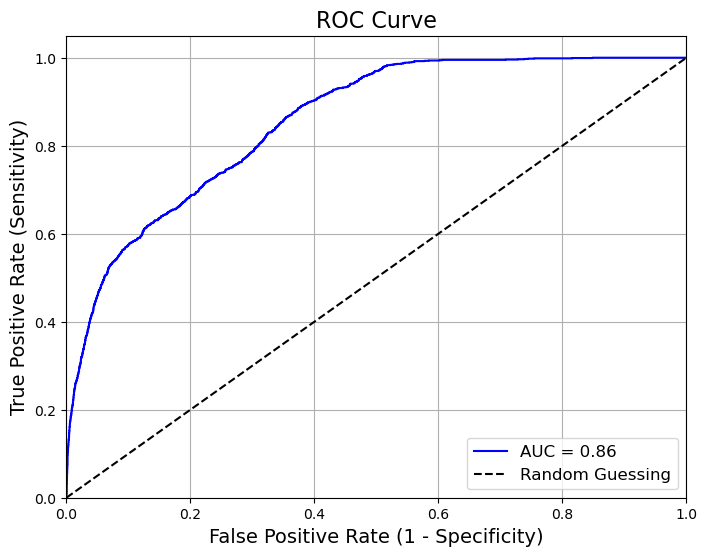

AUC Score: 0.86


In [91]:
# plot RUC curve
plot_roc_curve(LR1, x_test_sc, y_test)

### DecisionTreeClassifier

* Decision Trees work by splitting the data into smaller and smaller subsets based on feature values, ultimately forming a tree where each leaf node represents a class label. It’s a model that can handle both numerical and categorical data and does not require much preprocessing.
* Suitability: Decision Trees are suitable for classification tasks where interpretability is crucial. The tree structure is easy to visualize and understand, making it useful for understanding decision rules.
* Pros and Cons: While they are interpretable and work well with both categorical and numerical data, Decision Trees are prone to overfitting, especially with deep trees, unless regularized.

In [92]:
from sklearn.tree import DecisionTreeClassifier
DT=DecisionTreeClassifier()
DT.fit(x_sm,y_sm)
y_predict=DT.predict(x_test_sc)
y_pre_train=DT.predict(x_sm)

In [93]:
acc_dt=accuracy_score(y_test,y_predict)
recall_dt=recall_score(y_test,y_predict,pos_label=1)
prec_dt=precision_score(y_test,y_predict,pos_label=1)
f1_dt=f1_score(y_test,y_predict,pos_label=1)
cl_dt=classification_report(y_test,y_predict)
cm_dt=confusion_matrix(y_test,y_predict)

print(f"Decision Tree TEST score:")
print(f"Decision Tree Accuracy score:{acc_dt}")
print(f"Decision Tree Recall score:{recall_dt}")
print(f"Decision Tree Precision score:{prec_dt}")
print(f"Decision Tree F1 score:{f1_dt}")
print(f"{cl_dt}")
print(f"Decision Tree Confusion Matrix:{cm_dt}")
# Visualize the confusion matrix
pd.crosstab(y_test,y_predict, rownames=['Actual'], colnames=['Predicted'])

Decision Tree TEST score:
Decision Tree Accuracy score:0.855338784101028
Decision Tree Recall score:0.42275280898876405
Decision Tree Precision score:0.3841735800893427
Decision Tree F1 score:0.40254095620193914
              precision    recall  f1-score   support

           0       0.92      0.91      0.92     10929
           1       0.38      0.42      0.40      1424

    accuracy                           0.86     12353
   macro avg       0.65      0.67      0.66     12353
weighted avg       0.86      0.86      0.86     12353

Decision Tree Confusion Matrix:[[9964  965]
 [ 822  602]]


Predicted,0,1
Actual,,
0,9964,965
1,822,602


In [94]:
acc_dt=accuracy_score(y_sm,y_pre_train)
recall_dt=recall_score(y_sm,y_pre_train,pos_label=1)
prec_dt=precision_score(y_sm,y_pre_train,pos_label=1)
f1_dt=f1_score(y_sm,y_pre_train,pos_label=1)
cl_dt=classification_report(y_sm,y_pre_train)
cm_dt=confusion_matrix(y_sm,y_pre_train)

print(f"Decision Tree TRAIN score:")
print(f"Decision Tree Accuracy score:{acc_dt}")
print(f"Decision Tree Recall score:{recall_dt}")
print(f"Decision Tree Precision score:{prec_dt}")
print(f"Decision Tree F1 score:{f1_dt}")
print(f"{cl_dt}")
print(f"Decision Tree Confusion Matrix:{cm_dt}")
# Visualize the confusion matrix
pd.crosstab(y_sm,y_pre_train, rownames=['Actual'], colnames=['Predicted'])

Decision Tree TRAIN score:
Decision Tree Accuracy score:0.9981451109028429
Decision Tree Recall score:0.996485473289597
Decision Tree Precision score:0.9998040982643106
Decision Tree F1 score:0.9981420273415345
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25608
           1       1.00      1.00      1.00     25608

    accuracy                           1.00     51216
   macro avg       1.00      1.00      1.00     51216
weighted avg       1.00      1.00      1.00     51216

Decision Tree Confusion Matrix:[[25603     5]
 [   90 25518]]


Predicted,0,1
Actual,,
0,25603,5
1,90,25518


In [95]:
params = {
    "criterion": ("gini", "entropy", "log_loss"),  # quality of split for classification
    "splitter": ("best", "random"),  # searches the features for a split
    "max_depth": [None, 5, 10, 15, 20],  # depth of tree range
    "min_samples_split": [2, 5, 10, 15],  # min samples required to split internal node
    "min_samples_leaf": [1, 2, 4, 6],  # min samples required at a leaf node
    "max_features": (None, "sqrt", "log2", 0.5, 0.8),  # features considered for the best split
    "max_leaf_nodes": [None, 10, 20, 30, 50, 100]  # max number of leaf nodes
}

tree_clf = DecisionTreeClassifier(random_state=42)
tree_cv = GridSearchCV(tree_clf, params, scoring='roc_auc', n_jobs=-1, cv=5)

tree_cv.fit(x_train,y_train)#training data on gridsearch cv
best_params = tree_cv.best_params_#it will give you best parameters
print(f"Best paramters: {best_params})")

Best paramters: {'criterion': 'entropy', 'max_depth': 10, 'max_features': None, 'max_leaf_nodes': 50, 'min_samples_leaf': 6, 'min_samples_split': 2, 'splitter': 'best'})


In [96]:
Bestparamters: ({'criterion': 'entropy', 'max_depth': 10, 'max_features': None, 'max_leaf_nodes': 50, 'min_samples_leaf': 6, 'min_samples_split': 2, 'splitter': 'best'})

In [97]:
DT1=DecisionTreeClassifier(criterion='entropy',max_depth=10,max_features=None,max_leaf_nodes=50,min_samples_leaf=6, min_samples_split=2,splitter='best')

In [98]:
DT1.fit(x_sm,y_sm)
y_predict=DT1.predict(x_test_sc)
y_pre_train=DT1.predict(x_sm)

In [99]:
acc_dt1=accuracy_score(y_test,y_predict)
recall_dt1=recall_score(y_test,y_predict,pos_label=1)
prec_dt1=precision_score(y_test,y_predict,pos_label=1)
f1_dt1=f1_score(y_test,y_predict,pos_label=1)
cl_dt1=classification_report(y_test,y_predict)
cm_dt1=confusion_matrix(y_test,y_predict)

print(f"Decision Tree TEST score after hyperparameter tuning:")
print(f"Decision Tree Accuracy score:{acc_dt1}")
print(f"Decision Tree Recall score:{recall_dt1}")
print(f"Decision Tree Precision score:{prec_dt1}")
print(f"Decision Tree F1 score:{f1_dt1}")
print(f"{cl_dt1}")
print(f"Decision Tree Confusion Matrix:{cm_dt1}")
# Visualize the confusion matrix
pd.crosstab(y_test,y_predict, rownames=['Actual'], colnames=['Predicted'])

Decision Tree TEST score after hyperparameter tuning:
Decision Tree Accuracy score:0.8670768234436979
Decision Tree Recall score:0.5575842696629213
Decision Tree Precision score:0.43964562569213733
Decision Tree F1 score:0.491640866873065
              precision    recall  f1-score   support

           0       0.94      0.91      0.92     10929
           1       0.44      0.56      0.49      1424

    accuracy                           0.87     12353
   macro avg       0.69      0.73      0.71     12353
weighted avg       0.88      0.87      0.87     12353

Decision Tree Confusion Matrix:[[9917 1012]
 [ 630  794]]


Predicted,0,1
Actual,,
0,9917,1012
1,630,794


In [100]:
acc_dt1=accuracy_score(y_sm,y_pre_train)
recall_dt1=recall_score(y_sm,y_pre_train,pos_label=1)
prec_dt1=precision_score(y_sm,y_pre_train,pos_label=1)
f1_dt1=f1_score(y_sm,y_pre_train,pos_label=1)
cl_dt1=classification_report(y_sm,y_pre_train)
cm_dt1=confusion_matrix(y_sm,y_pre_train)

print(f"Decision Tree TRAIN score after hyperparameter tuning:")
print(f"Decision Tree Accuracy score:{acc_dt1}")
print(f"Decision Tree Recall score:{recall_dt1}")
print(f"Decision Tree Precision score:{prec_dt1}")
print(f"Decision Tree F1 score:{f1_dt1}")
print(f"{cl_dt1}")
print(f"Decision Tree Confusion Matrix:{cm_dt1}")
# Visualize the confusion matrix
pd.crosstab(y_sm,y_pre_train, rownames=['Actual'], colnames=['Predicted'])

Decision Tree TRAIN score after hyperparameter tuning:
Decision Tree Accuracy score:0.8738675413933146
Decision Tree Recall score:0.8410262417994376
Decision Tree Precision score:0.9001504639304523
Decision Tree F1 score:0.8695845277990875
              precision    recall  f1-score   support

           0       0.85      0.91      0.88     25608
           1       0.90      0.84      0.87     25608

    accuracy                           0.87     51216
   macro avg       0.88      0.87      0.87     51216
weighted avg       0.88      0.87      0.87     51216

Decision Tree Confusion Matrix:[[23219  2389]
 [ 4071 21537]]


Predicted,0,1
Actual,,
0,23219,2389
1,4071,21537


Decision Tree AUC: 0.87


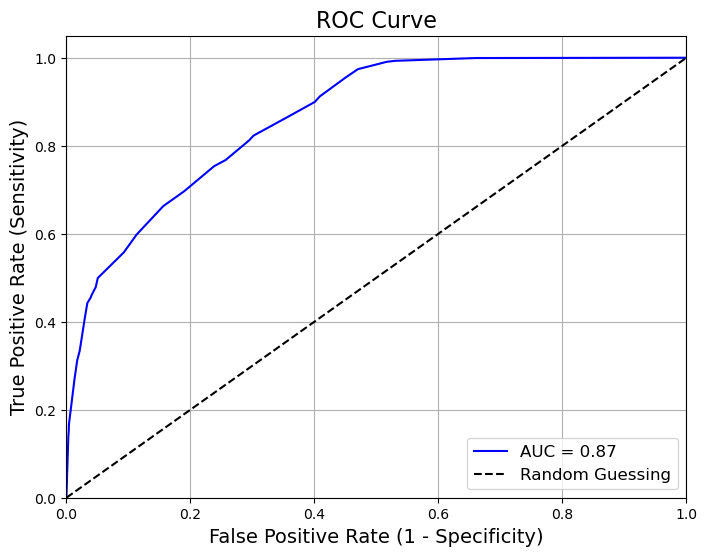

AUC Score: 0.87


In [101]:
# Get predicted probabilities for the positive class
y_probs_logreg = DT1.predict_proba(x_test_sc)[:, 1]

# Calculate AUC score
auc_logreg = roc_auc_score(y_test, y_probs_logreg)
print(f"Decision Tree AUC: {auc_logreg:.2f}")

# plot RUC curve
plot_roc_curve(DT1, x_test_sc, y_test)

### RandomForestClassifier

*  Random Forest is an ensemble learning method that builds multiple decision trees and combines their outputs to improve prediction accuracy and control overfitting. Each tree is trained on a different random subset of the data, making the model more robust.
*  Suitability: Random Forest is highly suitable for classification tasks with complex relationships between features. It performs well in a wide variety of tasks and is less likely to overfit compared to a single decision tree.
*  Pros and Cons: It’s powerful and reduces the risk of overfitting, but it can be slower to train and harder to interpret compared to simpler models like Logistic Regression or a single Decision Tree.

In [102]:
from sklearn.ensemble import RandomForestClassifier
RF=RandomForestClassifier(n_estimators=100,random_state=42)
RF.fit(x_sm,y_sm)
y_predict=RF.predict(x_test_sc)
y_pre_train=RF.predict(x_sm)

In [103]:
acc_rf=accuracy_score(y_test,y_predict)
recall_rf=recall_score(y_test,y_predict,pos_label=1)
prec_rf=precision_score(y_test,y_predict,pos_label=1)
f1_rf=f1_score(y_test,y_predict,pos_label=1)
cl_rf=classification_report(y_test,y_predict)
cm_rf=confusion_matrix(y_test,y_predict)

print(f"Random Forest TEST score:")
print(f"Random Forest Accuracy score:{acc_rf}")
print(f"Random Forest Recall score:{recall_rf}")
print(f"Random Forest Precision score:{prec_rf}")
print(f"Random Forest F1 score:{f1_rf}")
print(f"{cl_rf}")
print(f"Random Forest Confusion Matrix:{cm_rf}")
# Visualize the confusion matrix
pd.crosstab(y_test,y_predict, rownames=['Actual'], colnames=['Predicted'])

Random Forest TEST score:
Random Forest Accuracy score:0.9001861895895734
Random Forest Recall score:0.45014044943820225
Random Forest Precision score:0.5875343721356554
Random Forest F1 score:0.509741550695825
              precision    recall  f1-score   support

           0       0.93      0.96      0.94     10929
           1       0.59      0.45      0.51      1424

    accuracy                           0.90     12353
   macro avg       0.76      0.70      0.73     12353
weighted avg       0.89      0.90      0.89     12353

Random Forest Confusion Matrix:[[10479   450]
 [  783   641]]


Predicted,0,1
Actual,,
0,10479,450
1,783,641


In [104]:
acc_rf=accuracy_score(y_sm,y_pre_train)
recall_rf=recall_score(y_sm,y_pre_train,pos_label=1)
prec_rf=precision_score(y_sm,y_pre_train,pos_label=1)
f1_rf=f1_score(y_sm,y_pre_train,pos_label=1)
cl_rf=classification_report(y_sm,y_pre_train)
cm_rf=confusion_matrix(y_sm,y_pre_train)

print(f"Random Forest TRAIN score:")
print(f"Random Forest Accuracy score:{acc_rf}")
print(f"Random Forest Recall score:{recall_rf}")
print(f"Random Forest Precision score:{prec_rf}")
print(f"Random Forest F1 score:{f1_rf}")
print(f"{cl_rf}")
print(f"Random Forest Confusion Matrix:{cm_rf}")
# Visualize the confusion matrix
pd.crosstab(y_sm,y_pre_train, rownames=['Actual'], colnames=['Predicted'])

Random Forest TRAIN score:
Random Forest Accuracy score:0.9981451109028429
Random Forest Recall score:0.9975007810059356
Random Forest Precision score:0.9987878787878788
Random Forest F1 score:0.998143914971768
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25608
           1       1.00      1.00      1.00     25608

    accuracy                           1.00     51216
   macro avg       1.00      1.00      1.00     51216
weighted avg       1.00      1.00      1.00     51216

Random Forest Confusion Matrix:[[25577    31]
 [   64 25544]]


Predicted,0,1
Actual,,
0,25577,31
1,64,25544


In [105]:
params = {
    'n_estimators': [100, 200, 500],    # represents the number of trees in the forest
    'max_depth': [None, 10, 20],        # sets the maximum depth of each tree
    'min_samples_split': [2, 5, 10],    # minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],      # minimum number of samples required to be at a leaf node.
    'max_features': ['auto', 'sqrt', 'log2'],  # Number of features to consider at each split
    'bootstrap': [True, False]          # decides whether bootstrap samples are used when building trees
}

forest_clf = RandomForestClassifier(random_state=42)
forest_cv = GridSearchCV(forest_clf, params, scoring='roc_auc', n_jobs=-1, cv=5)

forest_cv.fit(x_train,y_train)#training data on gridsearch cv
best_params = forest_cv.best_params_#it will give you best parameters
print(f"Best paramters: {best_params})")

Best paramters: {'bootstrap': False, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100})


In [106]:
Bestparamters: ({'bootstrap': False, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100})

In [107]:
RF1=RandomForestClassifier(bootstrap=False,max_depth=10,max_features='sqrt',min_samples_leaf=4,min_samples_split=10,n_estimators=100)

In [108]:
RF1.fit(x_sm,y_sm)
y_predict=RF1.predict(x_test_sc)
y_pre_train=RF1.predict(x_sm)

In [109]:
acc_rf1=accuracy_score(y_test,y_predict)
recall_rf1=recall_score(y_test,y_predict,pos_label=1)
prec_rf1=precision_score(y_test,y_predict,pos_label=1)
f1_rf1=f1_score(y_test,y_predict,pos_label=1)
cl_rf1=classification_report(y_test,y_predict)
cm_rf1=confusion_matrix(y_test,y_predict)

print(f"Random Forest TEST score after HP Tuning:")
print(f"Random Forest Accuracy score:{acc_rf1}")
print(f"Random Forest Recall score:{recall_rf1}")
print(f"Random Forest Precision score:{prec_rf1}")
print(f"Random Forest F1 score:{f1_rf1}")
print(f"{cl_rf1}")
print(f"Random Forest Confusion Matrix:{cm_rf1}")
# Visualize the confusion matrix
pd.crosstab(y_test,y_predict, rownames=['Actual'], colnames=['Predicted'])

Random Forest TEST score after HP Tuning:
Random Forest Accuracy score:0.8669958714482312
Random Forest Recall score:0.6383426966292135
Random Forest Precision score:0.44624447717231225
Random Forest F1 score:0.5252817104882982
              precision    recall  f1-score   support

           0       0.95      0.90      0.92     10929
           1       0.45      0.64      0.53      1424

    accuracy                           0.87     12353
   macro avg       0.70      0.77      0.72     12353
weighted avg       0.89      0.87      0.88     12353

Random Forest Confusion Matrix:[[9801 1128]
 [ 515  909]]


Predicted,0,1
Actual,,
0,9801,1128
1,515,909


In [110]:
acc_rf1=accuracy_score(y_sm,y_pre_train)
recall_rf1=recall_score(y_sm,y_pre_train,pos_label=1)
prec_rf1=precision_score(y_sm,y_pre_train,pos_label=1)
f1_rf1=f1_score(y_sm,y_pre_train,pos_label=1)
cl_rf1=classification_report(y_sm,y_pre_train)
cm_rf1=confusion_matrix(y_sm,y_pre_train)

print(f"Random Forest TRAIN score after HP Tuning:")
print(f"Random Forest Accuracy score:{acc_rf1}")
print(f"Random Forest Recall score:{recall_rf1}")
print(f"Random Forest Precision score:{prec_rf1}")
print(f"Random Forest F1 score:{f1_rf1}")
print(f"{cl_rf1}")
print(f"Random Forest Confusion Matrix:{cm_rf1}")
# Visualize the confusion matrix
pd.crosstab(y_sm,y_pre_train, rownames=['Actual'], colnames=['Predicted'])

Random Forest TRAIN score after HP Tuning:
Random Forest Accuracy score:0.9173890971571383
Random Forest Recall score:0.9295142143080287
Random Forest Precision score:0.9075069579473102
Random Forest F1 score:0.9183787642031753
              precision    recall  f1-score   support

           0       0.93      0.91      0.92     25608
           1       0.91      0.93      0.92     25608

    accuracy                           0.92     51216
   macro avg       0.92      0.92      0.92     51216
weighted avg       0.92      0.92      0.92     51216

Random Forest Confusion Matrix:[[23182  2426]
 [ 1805 23803]]


Predicted,0,1
Actual,,
0,23182,2426
1,1805,23803


Random Forest AUC: 0.88


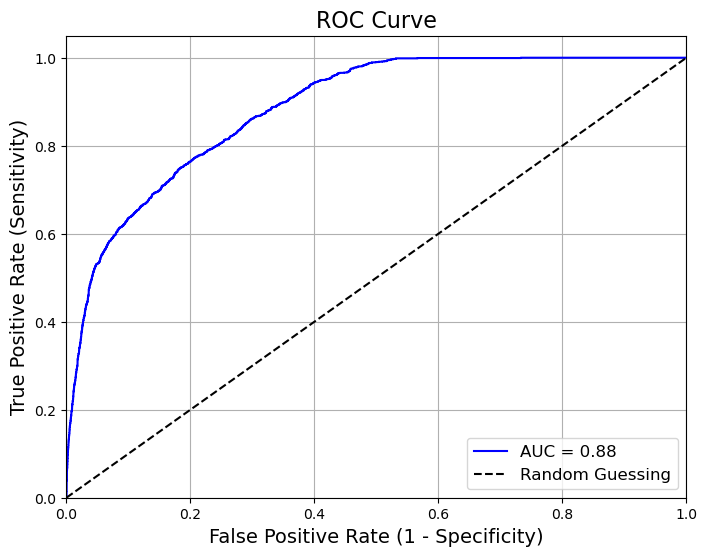

AUC Score: 0.88


In [111]:
# Get predicted probabilities for the positive class
y_probs_logreg = RF1.predict_proba(x_test_sc)[:, 1]

# Calculate AUC score
auc_logreg = roc_auc_score(y_test, y_probs_logreg)
print(f"Random Forest AUC: {auc_logreg:.2f}")

# plot RUC curve
plot_roc_curve(RF1, x_test_sc, y_test)

### KNeighborsClassifier

* KNN is a non-parametric, instance-based learning algorithm. It classifies a data point by looking at the 'k' closest points (neighbors) and assigning the majority class from the neighbors. It’s simple but relies heavily on the choice of distance metric.
* Suitability: KNN is suitable for smaller datasets where the relationships between features are highly local. It’s simple and doesn’t assume any particular form of the data, making it useful in many situations.
* Pros and Cons: It’s easy to understand and implement but can be computationally expensive and slow for large datasets. It also doesn’t perform well in high-dimensional spaces.

In [112]:
from sklearn.neighbors import KNeighborsClassifier
KNC=KNeighborsClassifier()
KNC.fit(x_sm,y_sm)
y_predict=KNC.predict(x_test_sc)
y_pre_train=KNC.predict(x_sm)

In [113]:
acc_knc=accuracy_score(y_test,y_predict)
recall_knc=recall_score(y_test,y_predict,pos_label=1)
prec_knc=precision_score(y_test,y_predict,pos_label=1)
f1_knc=f1_score(y_test,y_predict,pos_label=1)
cl_knc=classification_report(y_test,y_predict)
cm_knc=confusion_matrix(y_test,y_predict)

print(f"KNeighbors TEST score:")
print(f"KNeighbors Accuracy score:{acc_knc}")
print(f"KNeighbors Recall score:{recall_knc}")
print(f"KNeighbors Precision score:{prec_knc}")
print(f"KNeighbors F1 score:{f1_knc}")
print(f"{cl_knc}")
print(f"KNeighbors Confusion Matrix:{cm_knc}")
# Visualize the confusion matrix
pd.crosstab(y_test,y_predict, rownames=['Actual'], colnames=['Predicted'])

KNeighbors TEST score:
KNeighbors Accuracy score:0.782401036185542
KNeighbors Recall score:0.6446629213483146
KNeighbors Precision score:0.29612903225806453
KNeighbors F1 score:0.40583554376657827
              precision    recall  f1-score   support

           0       0.95      0.80      0.87     10929
           1       0.30      0.64      0.41      1424

    accuracy                           0.78     12353
   macro avg       0.62      0.72      0.64     12353
weighted avg       0.87      0.78      0.81     12353

KNeighbors Confusion Matrix:[[8747 2182]
 [ 506  918]]


Predicted,0,1
Actual,,
0,8747,2182
1,506,918


In [114]:
acc_knc=accuracy_score(y_sm,y_pre_train)
recall_knc=recall_score(y_sm,y_pre_train,pos_label=1)
prec_knc=precision_score(y_sm,y_pre_train,pos_label=1)
f1_knc=f1_score(y_sm,y_pre_train,pos_label=1)
cl_knc=classification_report(y_sm,y_pre_train)
cm_knc=confusion_matrix(y_sm,y_pre_train)

print(f"KNeighbors TRAIN score:")
print(f"KNeighbors Accuracy score:{acc_knc}")
print(f"KNeighbors Recall score:{recall_knc}")
print(f"KNeighbors Precision score:{prec_knc}")
print(f"KNeighbors F1 score:{f1_knc}")
print(f"{cl_knc}")
print(f"KNeighbors Confusion Matrix:{cm_knc}")
# Visualize the confusion matrix
pd.crosstab(y_sm,y_pre_train, rownames=['Actual'], colnames=['Predicted'])

KNeighbors TRAIN score:
KNeighbors Accuracy score:0.9230709153389566
KNeighbors Recall score:0.9962902218056857
KNeighbors Precision score:0.8690305879147081
KNeighbors F1 score:0.9283193246734345
              precision    recall  f1-score   support

           0       1.00      0.85      0.92     25608
           1       0.87      1.00      0.93     25608

    accuracy                           0.92     51216
   macro avg       0.93      0.92      0.92     51216
weighted avg       0.93      0.92      0.92     51216

KNeighbors Confusion Matrix:[[21763  3845]
 [   95 25513]]


Predicted,0,1
Actual,,
0,21763,3845
1,95,25513


In [115]:
from skopt import BayesSearchCV

# Define the parameter grid
params={
    'n_neighbors':(3, 20),  # it controls the number of nearest neighbors considered in the prediction.
    'weights':['uniform','distance'],     # defines whether all neighbors are weighted equally (uniform) or closer neighbors have more influence (distance).
    'metric':['euclidean','manhattan','minkowski'],      # defines the distance metric used to find neighbors.
    'p':(1, 5)           # minlowski distance parameter,with p=1 being manhatten and p=2 being euclidean
}
neighbors_clf = KNeighborsClassifier()
neighbors_cv = BayesSearchCV(neighbors_clf, params, n_iter=50, scoring='roc_auc',verbose=2, n_jobs=-1, cv=5)
## BayesSearchCV is the main function that integrates Bayesian Optimization with the model tuning process.
## It iteratively evaluates the model with different hyperparameters,guided by the aquisition function. 

neighbors_cv.fit(x_train,y_train)#training data on gridsearch cv
best_params = neighbors_cv.best_params_#it will give you best parameters
print(f"Best paramters: {best_params})")

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

In [116]:
Bestparamters: ({'metric': 'manhattan', 'n_neighbors': 20, 'p': 1, 'weights': 'uniform'})

In [117]:
KNC1= KNeighborsClassifier(metric='manhattan',n_neighbors=20,p=1,weights='uniform')

In [118]:
KNC1.fit(x_sm,y_sm)
y_predict=KNC1.predict(x_test_sc)
y_pre_train=KNC1.predict(x_sm)

In [119]:
acc_knc1=accuracy_score(y_test,y_predict)
recall_knc1=recall_score(y_test,y_predict,pos_label=1)
prec_knc1=precision_score(y_test,y_predict,pos_label=1)
f1_knc1=f1_score(y_test,y_predict,pos_label=1)
cl_knc1=classification_report(y_test,y_predict)
cm_knc1=confusion_matrix(y_test,y_predict)

print(f"KNeighbors TEST score after HP Tuning:")
print(f"KNeighbors Accuracy score after :{acc_knc1}")
print(f"KNeighbors Recall score:{recall_knc1}")
print(f"KNeighbors Precision score:{prec_knc1}")
print(f"KNeighbors F1 score:{f1_knc1}")
print(f"{cl_knc1}")
print(f"KNeighbors Confusion Matrix:{cm_knc1}")
# Visualize the confusion matrix
pd.crosstab(y_test,y_predict, rownames=['Actual'], colnames=['Predicted'])

KNeighbors TEST score after HP Tuning:
KNeighbors Accuracy score after :0.7951914514692787
KNeighbors Recall score:0.675561797752809
KNeighbors Precision score:0.3174917491749175
KNeighbors F1 score:0.4319712617871576
              precision    recall  f1-score   support

           0       0.95      0.81      0.88     10929
           1       0.32      0.68      0.43      1424

    accuracy                           0.80     12353
   macro avg       0.63      0.74      0.65     12353
weighted avg       0.88      0.80      0.82     12353

KNeighbors Confusion Matrix:[[8861 2068]
 [ 462  962]]


Predicted,0,1
Actual,,
0,8861,2068
1,462,962


In [120]:
acc_knc1=accuracy_score(y_sm,y_pre_train)
recall_knc1=recall_score(y_sm,y_pre_train,pos_label=1)
prec_knc1=precision_score(y_sm,y_pre_train,pos_label=1)
f1_knc1=f1_score(y_sm,y_pre_train,pos_label=1)
cl_knc1=classification_report(y_sm,y_pre_train)
cm_knc1=confusion_matrix(y_sm,y_pre_train)

print(f"KNeighbors TRAIN score after HP Tuning:")
print(f"KNeighbors Accuracy score:{acc_knc1}")
print(f"KNeighbors Recall score:{recall_knc1}")
print(f"KNeighbors Precision score:{prec_knc1}")
print(f"KNeighbors F1 score:{f1_knc1}")
print(f"{cl_knc1}")
print(f"KNeighbors Confusion Matrix:{cm_knc1}")
# Visualize the confusion matrix
pd.crosstab(y_sm,y_pre_train, rownames=['Actual'], colnames=['Predicted'])

KNeighbors TRAIN score after HP Tuning:
KNeighbors Accuracy score:0.8923578569197126
KNeighbors Recall score:0.9501327710090597
KNeighbors Precision score:0.8517170161375013
KNeighbors F1 score:0.8982371942778035
              precision    recall  f1-score   support

           0       0.94      0.83      0.89     25608
           1       0.85      0.95      0.90     25608

    accuracy                           0.89     51216
   macro avg       0.90      0.89      0.89     51216
weighted avg       0.90      0.89      0.89     51216

KNeighbors Confusion Matrix:[[21372  4236]
 [ 1277 24331]]


Predicted,0,1
Actual,,
0,21372,4236
1,1277,24331


KNeighbors AUC: 0.82


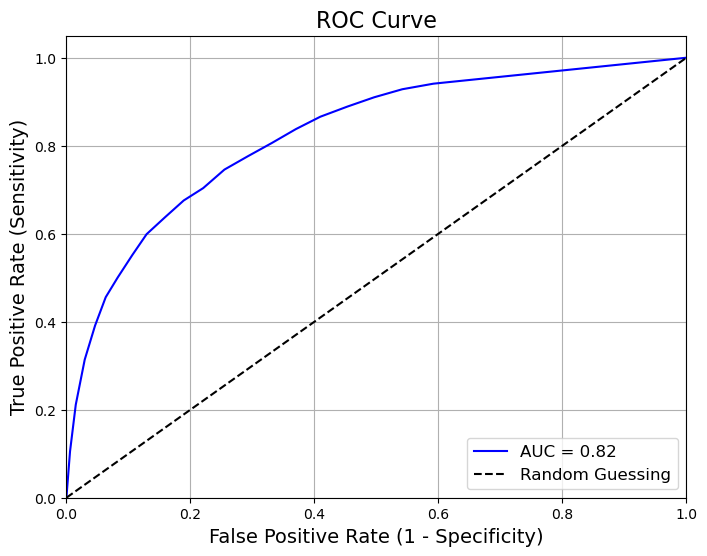

AUC Score: 0.82


In [121]:
# Get predicted probabilities for the positive class
y_probs_logreg = KNC1.predict_proba(x_test_sc)[:, 1]

# Calculate AUC score
auc_logreg = roc_auc_score(y_test, y_probs_logreg)
print(f"KNeighbors AUC: {auc_logreg:.2f}")

# plot RUC curve
plot_roc_curve(KNC1, x_test_sc, y_test)

### GradientBoostingClassifier

* Gradient Boosting is an ensemble technique that builds decision trees sequentially, where each tree corrects the errors of the previous one. Unlike Random Forest, where trees are built independently, Gradient Boosting trees are trained to minimize the error of the combined model.
* Suitability: Gradient Boosting is suitable for complex classification tasks where high accuracy is needed. It is more powerful than Random Forest but requires careful tuning to avoid overfitting.
* Pros and Cons: It can achieve high accuracy but is prone to overfitting and may require more computational resources compared to simpler models. It also requires careful hyperparameter tuning.

In [122]:
from sklearn.ensemble import GradientBoostingClassifier
GBC=GradientBoostingClassifier()
GBC.fit(x_sm,y_sm)
y_predict=GBC.predict(x_test_sc)
y_pre_train=GBC.predict(x_sm)

In [123]:
acc_gbc=accuracy_score(y_test,y_predict)
recall_gbc=recall_score(y_test,y_predict,pos_label=1)
prec_gbc=precision_score(y_test,y_predict,pos_label=1)
f1_gbc=f1_score(y_test,y_predict,pos_label=1)
cl_gbc=classification_report(y_test,y_predict)
cm_gbc=confusion_matrix(y_test,y_predict)

print(f"GradientBoostingClassifier TEST score:")
print(f"GradientBoostingClassifier Accuracy score:{acc_gbc}")
print(f"GradientBoostingClassifier Recall score:{recall_gbc}")
print(f"GradientBoostingClassifier Precision score:{prec_gbc}")
print(f"GradientBoostingClassifier F1 score:{f1_gbc}")
print(f"{cl_gbc}")
print(f"GradientBoostingClassifier Confusion Matrix:{cm_gbc}")
# Visualize the confusion matrix
pd.crosstab(y_test,y_predict, rownames=['Actual'], colnames=['Predicted'])

GradientBoostingClassifier TEST score:
GradientBoostingClassifier Accuracy score:0.9029385574354408
GradientBoostingClassifier Recall score:0.48735955056179775
GradientBoostingClassifier Precision score:0.5967325881341359
GradientBoostingClassifier F1 score:0.5365287978353305
              precision    recall  f1-score   support

           0       0.93      0.96      0.95     10929
           1       0.60      0.49      0.54      1424

    accuracy                           0.90     12353
   macro avg       0.77      0.72      0.74     12353
weighted avg       0.90      0.90      0.90     12353

GradientBoostingClassifier Confusion Matrix:[[10460   469]
 [  730   694]]


Predicted,0,1
Actual,,
0,10460,469
1,730,694


In [124]:
acc_gbc=accuracy_score(y_sm,y_pre_train)
recall_gbc=recall_score(y_sm,y_pre_train,pos_label=1)
prec_gbc=precision_score(y_sm,y_pre_train,pos_label=1)
f1_gbc=f1_score(y_sm,y_pre_train,pos_label=1)
cl_gbc=classification_report(y_sm,y_pre_train)
cm_gbc=confusion_matrix(y_sm,y_pre_train)

print(f"GradientBoostingClassifier TRAIN score:")
print(f"GradientBoostingClassifier Accuracy score:{acc_gbc}")
print(f"GradientBoostingClassifier Recall score:{recall_gbc}")
print(f"GradientBoostingClassifier Precision score:{prec_gbc}")
print(f"GradientBoostingClassifier F1 score:{f1_gbc}")
print(f"{cl_gbc}")
print(f"GradientBoostingClassifier Confusion Matrix:{cm_gbc}")
# Visualize the confusion matrix
pd.crosstab(y_sm,y_pre_train, rownames=['Actual'], colnames=['Predicted'])

GradientBoostingClassifier TRAIN score:
GradientBoostingClassifier Accuracy score:0.9333411433926898
GradientBoostingClassifier Recall score:0.9075679475164011
GradientBoostingClassifier Precision score:0.9568922924901185
GradientBoostingClassifier F1 score:0.9315776815776816
              precision    recall  f1-score   support

           0       0.91      0.96      0.94     25608
           1       0.96      0.91      0.93     25608

    accuracy                           0.93     51216
   macro avg       0.93      0.93      0.93     51216
weighted avg       0.93      0.93      0.93     51216

GradientBoostingClassifier Confusion Matrix:[[24561  1047]
 [ 2367 23241]]


Predicted,0,1
Actual,,
0,24561,1047
1,2367,23241


In [125]:
params ={
    'n_estimators': [100, 200, 500],     # represents the number of trees in the forest
    'learning_rate': [0.01, 0.1, 0.2],   # the contribution of each tree
    'max_depth': [3, 5, 7],              # sets the maximum depth of each tree
    'min_samples_split': [2, 5, 10],     # minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],       # minimum number of samples required to be at a leaf node.
    'subsample': [0.8, 1.0]              # the fraction of samples to be used for fitting the individual base learners
}

boosting_clf = GradientBoostingClassifier()
boosting_cv = RandomizedSearchCV(boosting_clf, params, n_iter=50, scoring='roc_auc', n_jobs=-1, cv=5)

boosting_cv.fit(x_train,y_train)#training data on gridsearch cv
best_params = boosting_cv.best_params_#it will give you best parameters
print(f"Best paramters: {best_params})")

Best paramters: {'subsample': 0.8, 'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 5, 'learning_rate': 0.1})


In [126]:
Bestparamters: ({'subsample': 0.8, 'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 5, 'learning_rate': 0.1})

In [127]:
GBC1= GradientBoostingClassifier(subsample=0.8,n_estimators=100,min_samples_split=2,min_samples_leaf=4,max_depth=5,learning_rate=0.1)

In [128]:
GBC1.fit(x_sm,y_sm)
y_predict=GBC1.predict(x_test_sc)
y_pre_train=GBC1.predict(x_sm)

In [129]:
acc_gbc1=accuracy_score(y_test,y_predict)
recall_gbc1=recall_score(y_test,y_predict,pos_label=1)
prec_gbc1=precision_score(y_test,y_predict,pos_label=1)
f1_gbc1=f1_score(y_test,y_predict,pos_label=1)
cl_gbc1=classification_report(y_test,y_predict)
cm_gbc1=confusion_matrix(y_test,y_predict)

print(f"GradientBoostingClassifier TEST score after HP Tuning:")
print(f"GradientBoostingClassifier Accuracy score:{acc_gbc1}")
print(f"GradientBoostingClassifier Recall score:{recall_gbc1}")
print(f"GradientBoostingClassifier Precision score:{prec_gbc1}")
print(f"GradientBoostingClassifier F1 score:{f1_gbc1}")
print(f"{cl_gbc1}")
print(f"GradientBoostingClassifier Confusion Matrix:{cm_gbc1}")
# Visualize the confusion matrix
pd.crosstab(y_test,y_predict, rownames=['Actual'], colnames=['Predicted'])

GradientBoostingClassifier TEST score after HP Tuning:
GradientBoostingClassifier Accuracy score:0.9076337731725087
GradientBoostingClassifier Recall score:0.4550561797752809
GradientBoostingClassifier Precision score:0.6396841066140178
GradientBoostingClassifier F1 score:0.5318013951579811
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     10929
           1       0.64      0.46      0.53      1424

    accuracy                           0.91     12353
   macro avg       0.79      0.71      0.74     12353
weighted avg       0.90      0.91      0.90     12353

GradientBoostingClassifier Confusion Matrix:[[10564   365]
 [  776   648]]


Predicted,0,1
Actual,,
0,10564,365
1,776,648


In [130]:
acc_gbc1=accuracy_score(y_sm,y_pre_train)
recall_gbc1=recall_score(y_sm,y_pre_train,pos_label=1)
prec_gbc1=precision_score(y_sm,y_pre_train,pos_label=1)
f1_gbc1=f1_score(y_sm,y_pre_train,pos_label=1)
cl_gbc1=classification_report(y_sm,y_pre_train)
cm_gbc1=confusion_matrix(y_sm,y_pre_train)

print(f"GradientBoostingClassifier TRAIN score after HP Tuning:")
print(f"GradientBoostingClassifier Accuracy score:{acc_gbc1}")
print(f"GradientBoostingClassifier Recall score:{recall_gbc1}")
print(f"GradientBoostingClassifier Precision score:{prec_gbc1}")
print(f"GradientBoostingClassifier F1 score:{f1_gbc1}")
print(f"{cl_gbc1}")
print(f"GradientBoostingClassifier Confusion Matrix:{cm_gbc1}")
# Visualize the confusion matrix
pd.crosstab(y_sm,y_pre_train, rownames=['Actual'], colnames=['Predicted'])

GradientBoostingClassifier TRAIN score after HP Tuning:
GradientBoostingClassifier Accuracy score:0.9475749765698219
GradientBoostingClassifier Recall score:0.9250624804748516
GradientBoostingClassifier Precision score:0.9686771621345328
GradientBoostingClassifier F1 score:0.946367576853165
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     25608
           1       0.97      0.93      0.95     25608

    accuracy                           0.95     51216
   macro avg       0.95      0.95      0.95     51216
weighted avg       0.95      0.95      0.95     51216

GradientBoostingClassifier Confusion Matrix:[[24842   766]
 [ 1919 23689]]


Predicted,0,1
Actual,,
0,24842,766
1,1919,23689


GradientBoostingClassifier AUC: 0.88


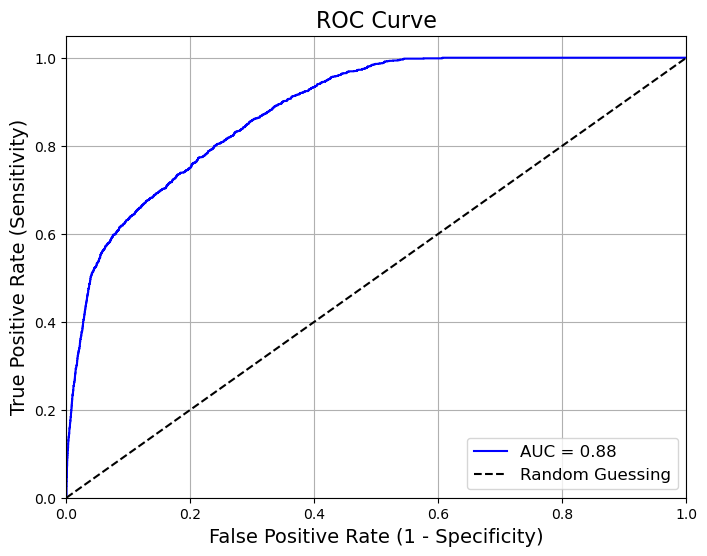

AUC Score: 0.88


In [131]:
# Get predicted probabilities for the positive class
y_probs_logreg = GBC1.predict_proba(x_test_sc)[:, 1]

# Calculate AUC score
auc_logreg = roc_auc_score(y_test, y_probs_logreg)
print(f"GradientBoostingClassifier AUC: {auc_logreg:.2f}")

# plot RUC curve
plot_roc_curve(GBC1, x_test_sc, y_test)

### XGBClassifier

* XGBoost (Extreme Gradient Boosting) is a highly efficient implementation of the gradient boosting algorithm. It is optimized for speed and performance, making it suitable for large-scale datasets. XGBoost uses regularization to prevent overfitting and can handle missing values naturally.
* Suitability: XGBoost is highly suitable for complex classification problems where model performance is critical. It performs exceptionally well on structured/tabular data.
* Pros and Cons: It’s highly accurate and fast but can be complex to tune, requiring careful selection of hyperparameters to avoid overfitting or underfitting.

In [132]:
from xgboost import XGBClassifier
XGBC=XGBClassifier(random_state=42)
XGBC.fit(x_sm,y_sm)
y_predict=XGBC.predict(x_test_sc)
y_pre_train=XGBC.predict(x_sm)

In [133]:
acc_xgbc=accuracy_score(y_test,y_predict)
recall_xgbc=recall_score(y_test,y_predict,pos_label=1)
prec_xgbc=precision_score(y_test,y_predict,pos_label=1)
f1_xgbc=f1_score(y_test,y_predict,pos_label=1)
cl_xgbc=classification_report(y_test,y_predict)
cm_xgbc=confusion_matrix(y_test,y_predict)

print(f"XGBClassifier TEST score:")
print(f"XGBClassifier Accuracy score:{acc_xgbc}")
print(f"XGBClassifier Recall score:{recall_xgbc}")
print(f"XGBClassifier Precision score:{prec_xgbc}")
print(f"XGBClassifier F1 score:{f1_xgbc}")
print(f"{cl_xgbc}")
print(f"XGBClassifier Confusion Matrix:{cm_xgbc}")
# Visualize the confusion matrix
pd.crosstab(y_test,y_predict, rownames=['Actual'], colnames=['Predicted'])

XGBClassifier TEST score:
XGBClassifier Accuracy score:0.9063385412450417
XGBClassifier Recall score:0.3967696629213483
XGBClassifier Precision score:0.6546929316338355
XGBClassifier F1 score:0.4940970703979012
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     10929
           1       0.65      0.40      0.49      1424

    accuracy                           0.91     12353
   macro avg       0.79      0.68      0.72     12353
weighted avg       0.89      0.91      0.90     12353

XGBClassifier Confusion Matrix:[[10631   298]
 [  859   565]]


Predicted,0,1
Actual,,
0,10631,298
1,859,565


In [134]:
acc_xgbc=accuracy_score(y_sm,y_pre_train)
recall_xgbc=recall_score(y_sm,y_pre_train,pos_label=1)
prec_xgbc=precision_score(y_sm,y_pre_train,pos_label=1)
f1_xgbc=f1_score(y_sm,y_pre_train,pos_label=1)
cl_xgbc=classification_report(y_sm,y_pre_train)
cm_xgbc=confusion_matrix(y_sm,y_pre_train)

print(f"XGBClassifier TRAIN score:")
print(f"XGBClassifier Accuracy score:{acc_xgbc}")
print(f"XGBClassifier Recall score:{recall_xgbc}")
print(f"XGBClassifier Precision score:{prec_xgbc}")
print(f"XGBClassifier F1 score:{f1_xgbc}")
print(f"{cl_xgbc}")
print(f"XGBClassifier Confusion Matrix:{cm_xgbc}")
# Visualize the confusion matrix
pd.crosstab(y_sm,y_pre_train, rownames=['Actual'], colnames=['Predicted'])

XGBClassifier TRAIN score:
XGBClassifier Accuracy score:0.9615354576694782
XGBClassifier Recall score:0.936426116838488
XGBClassifier Precision score:0.9859386563604967
XGBClassifier F1 score:0.9605447626677348
              precision    recall  f1-score   support

           0       0.94      0.99      0.96     25608
           1       0.99      0.94      0.96     25608

    accuracy                           0.96     51216
   macro avg       0.96      0.96      0.96     51216
weighted avg       0.96      0.96      0.96     51216

XGBClassifier Confusion Matrix:[[25266   342]
 [ 1628 23980]]


Predicted,0,1
Actual,,
0,25266,342
1,1628,23980


In [135]:
params={
    'n_estimators':[100,200,300],   # represents the number of trees in the forest
    'learning_rate':[0.01,0.1,0.2],  # the contribution of each tree
    'max_depth':[3,5,7],            # sets the maximum depth of each tree
    'min_child_weight': [1,3,5],   # minimum sum of instance weights (Hessian) needed in a child node
    'subsample':[0.8,1.0],         # the fraction of samples to be used for fitting the individual base learners
    'colsample_bytree':[0.8,1.0],  # fraction of features used for each tree.
    'gamma':[0,0.1,0.5]     # minimum loss reduction required to make a further partition on a leaf node.
}

Xboosting_clf =XGBClassifier(enable_categorical=True)
Xboosting_cv = GridSearchCV(Xboosting_clf, params, scoring='roc_auc', n_jobs=-1, cv=5)

Xboosting_cv.fit(x_train,y_train)#training data on gridsearch cv
best_params = Xboosting_cv.best_params_#it will give you best parameters
print(f"Best paramters: ({best_params})")

Best paramters: ({'colsample_bytree': 1.0, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 100, 'subsample': 0.8})


In [136]:
Bestparamters: ({'colsample_bytree': 1.0, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 100, 'subsample': 0.8})

In [137]:
XGBC1=XGBClassifier(colsample_bytree=1.0,gamma=0.1,learning_rate=0.1,max_depth=5,min_child_weight=5,n_estimators=100,subsample=0.8)

In [138]:
XGBC1.fit(x_sm,y_sm)
y_predict=XGBC1.predict(x_test_sc)
y_pre_train=XGBC1.predict(x_sm)

In [139]:
acc_xgbc1=accuracy_score(y_test,y_predict)
recall_xgbc1=recall_score(y_test,y_predict,pos_label=1)
prec_xgbc1=precision_score(y_test,y_predict,pos_label=1)
f1_xgbc1=f1_score(y_test,y_predict,pos_label=1)
cl_xgbc1=classification_report(y_test,y_predict)
cm_xgbc1=confusion_matrix(y_test,y_predict)

print(f"XGBClassifier TEST score after HP Tuning:")
print(f"XGBClassifier Accuracy score:{acc_xgbc1}")
print(f"XGBClassifier Recall score:{recall_xgbc1}")
print(f"XGBClassifier Precision score:{prec_xgbc1}")
print(f"XGBClassifier F1 score:{f1_xgbc1}")
print(f"{cl_xgbc1}")
print(f"XGBClassifier Confusion Matrix:{cm_xgbc1}")
# Visualize the confusion matrix
pd.crosstab(y_test,y_predict, rownames=['Actual'], colnames=['Predicted'])

XGBClassifier TEST score after HP Tuning:
XGBClassifier Accuracy score:0.905205213308508
XGBClassifier Recall score:0.4473314606741573
XGBClassifier Precision score:0.623898139079334
XGBClassifier F1 score:0.5210633946830265
              precision    recall  f1-score   support

           0       0.93      0.96      0.95     10929
           1       0.62      0.45      0.52      1424

    accuracy                           0.91     12353
   macro avg       0.78      0.71      0.73     12353
weighted avg       0.90      0.91      0.90     12353

XGBClassifier Confusion Matrix:[[10545   384]
 [  787   637]]


Predicted,0,1
Actual,,
0,10545,384
1,787,637


In [140]:
acc_xgbc1=accuracy_score(y_sm,y_pre_train)
recall_xgbc1=recall_score(y_sm,y_pre_train,pos_label=1)
prec_xgbc1=precision_score(y_sm,y_pre_train,pos_label=1)
f1_xgbc1=f1_score(y_sm,y_pre_train,pos_label=1)
cl_xgbc1=classification_report(y_sm,y_pre_train)
cm_xgbc1=confusion_matrix(y_sm,y_pre_train)

print(f"XGBClassifier TRAIN score after HP Tuning:")
print(f"XGBClassifier Accuracy score:{acc_xgbc1}")
print(f"XGBClassifier Recall score:{recall_xgbc1}")
print(f"XGBClassifier Precision score:{prec_xgbc1}")
print(f"XGBClassifier F1 score:{f1_xgbc1}")
print(f"{cl_xgbc1}")
print(f"XGBClassifier Confusion Matrix:{cm_xgbc1}")
# Visualize the confusion matrix
pd.crosstab(y_sm,y_pre_train, rownames=['Actual'], colnames=['Predicted'])

XGBClassifier TRAIN score after HP Tuning:
XGBClassifier Accuracy score:0.9432013433302093
XGBClassifier Recall score:0.918541080912215
XGBClassifier Precision score:0.9661942904087082
XGBClassifier F1 score:0.9417652593437832
              precision    recall  f1-score   support

           0       0.92      0.97      0.94     25608
           1       0.97      0.92      0.94     25608

    accuracy                           0.94     51216
   macro avg       0.94      0.94      0.94     51216
weighted avg       0.94      0.94      0.94     51216

XGBClassifier Confusion Matrix:[[24785   823]
 [ 2086 23522]]


Predicted,0,1
Actual,,
0,24785,823
1,2086,23522


XGBClassifier AUC: 0.88


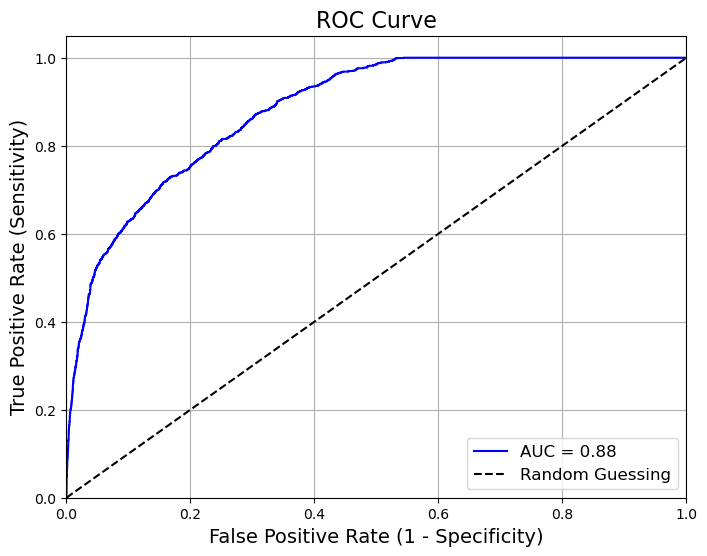

AUC Score: 0.88


In [141]:
# Get predicted probabilities for the positive class
y_probs_logreg = XGBC1.predict_proba(x_test_sc)[:, 1]

# Calculate AUC score
auc_logreg = roc_auc_score(y_test, y_probs_logreg)
print(f"XGBClassifier AUC: {auc_logreg:.2f}")

# plot RUC curve
plot_roc_curve(XGBC1, x_test_sc, y_test)

### LGBMClassifier

*  LightGBM is a gradient boosting framework that uses tree-based learning algorithms. It is designed to be faster and more efficient than XGBoost, especially for large datasets, by using leaf-wise growth.
*  Suitability: LightGBM is suitable for very large datasets and high-dimensional data, as it provides fast training and low memory usage. It performs well on classification tasks where speed is a priority.
*  Pros and Cons: LightGBM is highly efficient and fast, especially with large datasets, but it may overfit smaller datasets or require careful tuning in certain cases.

In [142]:
from lightgbm import LGBMClassifier
LGBMC=LGBMClassifier(random_state=42)
LGBMC.fit(x_sm,y_sm)
y_predict=LGBMC.predict(x_test_sc)
y_pre_train=LGBMC.predict(x_sm)

[LightGBM] [Info] Number of positive: 25608, number of negative: 25608
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005737 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4860
[LightGBM] [Info] Number of data points in the train set: 51216, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


In [143]:
acc_lgbm=accuracy_score(y_test,y_predict)
recall_lgbm=recall_score(y_test,y_predict,pos_label=1)
prec_lgbm=precision_score(y_test,y_predict,pos_label=1)
f1_lgbm=f1_score(y_test,y_predict,pos_label=1)
cl_lgbm=classification_report(y_test,y_predict)
cm_lgbm=confusion_matrix(y_test,y_predict)

print(f"LGBMClassifier TEST score:")
print(f"LGBMClassifier Accuracy score:{acc_lgbm}")
print(f"LGBMClassifier Recall score:{recall_lgbm}")
print(f"LGBMClassifier Precision score:{prec_lgbm}")
print(f"LGBMClassifier F1 score:{f1_lgbm}")
print(f"{cl_lgbm}")
print(f"LGBMClassifier Confusion Matrix:{cm_lgbm}")
# Visualize the confusion matrix
pd.crosstab(y_test,y_predict, rownames=['Actual'], colnames=['Predicted'])

LGBMClassifier TEST score:
LGBMClassifier Accuracy score:0.9074718691815753
LGBMClassifier Recall score:0.413623595505618
LGBMClassifier Precision score:0.6566332218506131
LGBMClassifier F1 score:0.5075398535114175
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     10929
           1       0.66      0.41      0.51      1424

    accuracy                           0.91     12353
   macro avg       0.79      0.69      0.73     12353
weighted avg       0.90      0.91      0.90     12353

LGBMClassifier Confusion Matrix:[[10621   308]
 [  835   589]]


Predicted,0,1
Actual,,
0,10621,308
1,835,589


In [144]:
acc_lgbm=accuracy_score(y_sm,y_pre_train)
recall_lgbm=recall_score(y_sm,y_pre_train,pos_label=1)
prec_lgbm=precision_score(y_sm,y_pre_train,pos_label=1)
f1_lgbm=f1_score(y_sm,y_pre_train,pos_label=1)
cl_lgbm=classification_report(y_sm,y_pre_train)
cm_lgbm=confusion_matrix(y_sm,y_pre_train)

print(f"LGBMClassifier TRAIN score:")
print(f"LGBMClassifier Accuracy score:{acc_lgbm}")
print(f"LGBMClassifier Recall score:{recall_lgbm}")
print(f"LGBMClassifier Precision score:{prec_lgbm}")
print(f"LGBMClassifier F1 score:{f1_lgbm}")
print(f"{cl_lgbm}")
print(f"LGBMClassifier Confusion Matrix:{cm_lgbm}")
# Visualize the confusion matrix
pd.crosstab(y_sm,y_pre_train, rownames=['Actual'], colnames=['Predicted'])

LGBMClassifier TRAIN score:
LGBMClassifier Accuracy score:0.9531786941580757
LGBMClassifier Recall score:0.9296313651983755
LGBMClassifier Precision score:0.9755757724776658
LGBMClassifier F1 score:0.9520495900819836
              precision    recall  f1-score   support

           0       0.93      0.98      0.95     25608
           1       0.98      0.93      0.95     25608

    accuracy                           0.95     51216
   macro avg       0.95      0.95      0.95     51216
weighted avg       0.95      0.95      0.95     51216

LGBMClassifier Confusion Matrix:[[25012   596]
 [ 1802 23806]]


Predicted,0,1
Actual,,
0,25012,596
1,1802,23806


In [145]:
params={
    'n_estimators':[100,200,300],   # represents the number of trees in the forest
    'learning_rate':[0.01, 0.05, 0.1, 0.2],  # the contribution of each tree
    'max_depth':[-1,5,7],  # sets the maximum depth of each tree
    'num_leaves': [20,30,40,50],  # specifies the maximum no of leaves in one tree
    'min_child_weight': [1,3,5],    # minimum sum of instance weights (Hessian) needed in a child node
    'colsample_bytree':[0.6,0.8,1.0],  # fraction of features used for each tree.
    'subsample':[0.6,0.8,1.0]         # the fraction of samples to be used for fitting the individual base learners
}

lgbm_C=RandomizedSearchCV(LGBMC,params,n_iter=50,cv=5,scoring="roc_auc",n_jobs=-1,verbose=1,random_state=32)
lgbm_C.fit(x_train,y_train)
best_params=lgbm_C.best_params_
print(f"Best Parameters:{best_params})")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[LightGBM] [Info] Number of positive: 3215, number of negative: 25608
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004953 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 406
[LightGBM] [Info] Number of data points in the train set: 28823, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.111543 -> initscore=-2.075077
[LightGBM] [Info] Start training from score -2.075077
Best Parameters:{'subsample': 1.0, 'num_leaves': 20, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 1.0})


In [146]:
BestParameters: ({'subsample': 1.0, 'num_leaves': 20, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 1.0})

In [147]:
LGBMC1=LGBMClassifier(subsample=1.0,num_leaves=20,n_estimators=200,min_child_weight=3,max_depth=-1,learning_rate=0.05,colsample_bytree=1.0)

In [148]:
LGBMC1.fit(x_sm,y_sm)
y_predict=LGBMC1.predict(x_test_sc)
y_pre_train=LGBMC1.predict(x_sm)

[LightGBM] [Info] Number of positive: 25608, number of negative: 25608
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011586 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4860
[LightGBM] [Info] Number of data points in the train set: 51216, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


In [149]:
acc_lgbm1=accuracy_score(y_test,y_predict)
recall_lgbm1=recall_score(y_test,y_predict,pos_label=1)
prec_lgbm1=precision_score(y_test,y_predict,pos_label=1)
f1_lgbm1=f1_score(y_test,y_predict,pos_label=1)
cl_lgbm1=classification_report(y_test,y_predict)
cm_lgbm1=confusion_matrix(y_test,y_predict)

print(f"LGBMClassifier TEST score after HP Tuning:")
print(f"LGBMClassifier Accuracy score:{acc_lgbm1}")
print(f"LGBMClassifier Recall score:{recall_lgbm1}")
print(f"LGBMClassifier Precision score:{prec_lgbm1}")
print(f"LGBMClassifier F1 score:{f1_lgbm1}")
print(f"{cl_lgbm1}")
print(f"LGBMClassifier Confusion Matrix:{cm_lgbm1}")
# Visualize the confusion matrix
pd.crosstab(y_test,y_predict, rownames=['Actual'], colnames=['Predicted'])

LGBMClassifier TEST score after HP Tuning:
LGBMClassifier Accuracy score:0.9074718691815753
LGBMClassifier Recall score:0.4353932584269663
LGBMClassifier Precision score:0.6465067778936392
LGBMClassifier F1 score:0.5203524968527067
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     10929
           1       0.65      0.44      0.52      1424

    accuracy                           0.91     12353
   macro avg       0.79      0.70      0.73     12353
weighted avg       0.90      0.91      0.90     12353

LGBMClassifier Confusion Matrix:[[10590   339]
 [  804   620]]


Predicted,0,1
Actual,,
0,10590,339
1,804,620


In [150]:
print(f"y_sm shape: {y_sm.shape}")
print(f"y_pre_train shape: {y_pre_train.shape}")

y_sm shape: (51216,)
y_pre_train shape: (51216,)


In [151]:
acc_lgbm1=accuracy_score(y_sm,y_pre_train)
recall_lgbm1=recall_score(y_sm,y_pre_train)
prec_lgbm1=precision_score(y_sm,y_pre_train)
f1_lgbm1=f1_score(y_sm,y_pre_train)
cl_lgbm1=classification_report(y_sm,y_pre_train)
cm_lgbm1=confusion_matrix(y_sm,y_pre_train)

print(f"LGBMClassifier TRAIN score after HP Tuning:")
print(f"LGBMClassifier Accuracy score:{acc_lgbm1}")
print(f"LGBMClassifier Recall score:{recall_lgbm1}")
print(f"LGBMClassifier Precision score:{prec_lgbm1}")
print(f"LGBMClassifier F1 score:{f1_lgbm1}")
print(f"{cl_lgbm1}")
print(f"LGBMClassifier Confusion Matrix:{cm_lgbm1}")
# Visualize the confusion matrix
pd.crosstab(y_sm, y_pre_train, rownames=['Actual'], colnames=['Predicted'])

LGBMClassifier TRAIN score after HP Tuning:
LGBMClassifier Accuracy score:0.948668384879725
LGBMClassifier Recall score:0.926663542642924
LGBMClassifier Precision score:0.9693231485641927
LGBMClassifier F1 score:0.9475134261015392
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     25608
           1       0.97      0.93      0.95     25608

    accuracy                           0.95     51216
   macro avg       0.95      0.95      0.95     51216
weighted avg       0.95      0.95      0.95     51216

LGBMClassifier Confusion Matrix:[[24857   751]
 [ 1878 23730]]


Predicted,0,1
Actual,,
0,24857,751
1,1878,23730


LGBMClassifier AUC: 0.89


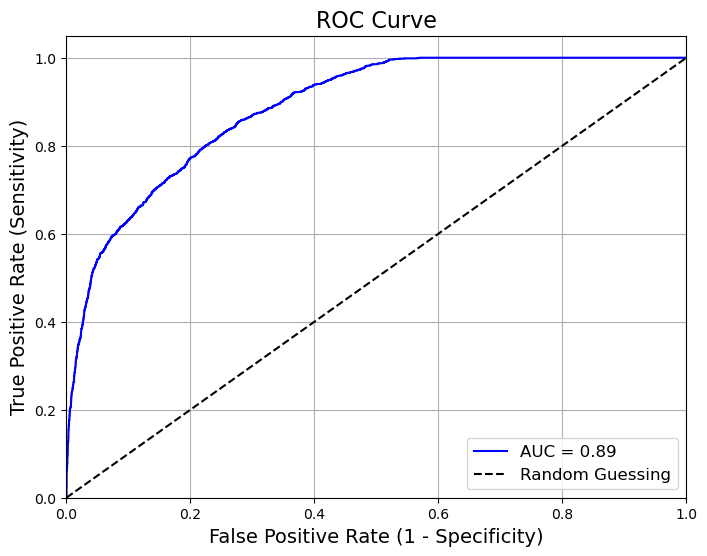

AUC Score: 0.89


In [152]:
# Get predicted probabilities for the positive class
y_probs_logreg = LGBMC1.predict_proba(x_test_sc)[:, 1]

# Calculate AUC score
auc_logreg = roc_auc_score(y_test, y_probs_logreg)
print(f"LGBMClassifier AUC: {auc_logreg:.2f}")

# plot RUC curve
plot_roc_curve(LGBMC1, x_test_sc, y_test)

## Task3:-Suggestions to the Bank market team to make customers buy the product.


    Here are some actionable suggestions for the bank marketing team to improve customer conversions and encourage more clients to subscribe to term deposit products:
#### 1) Segment Customers Based on Age and Income Profiles:
* Different age groups have varied saving and investment priorities. For example, younger clients may be more focused on short-term liquidity, while 
older clients might be more inclined to save for retirement.
* Action: Tailor marketing campaigns for different age groups. Younger clients could be targeted with flexible deposit options, while older clients can be offered high-interest long-term deposits for retirement savings.
#### 2) Leverage Employment Data for Targeting:
* Clients in higher-income professions (like management, executives) may be more inclined to invest in term deposits. Similarly, salaried individuals or those in stable professions might prefer low-risk savings options.
* Action: Use job information to identify high-potential clients for term deposit marketing. Offer specific packages based on job categories and financial needs.
#### 3) Capitalize on Economic and Market Trends:
* The Euribor rate, employment variation rate, and consumer confidence index are key indicators of economic health. Clients are more likely to save in periods of economic stability or rising interest rates.
* Action: Time campaigns based on favorable market conditions such as higher Euribor rates, which might increase the appeal of savings products. Use economic forecasts to plan promotional efforts around times when customers are likely to feel financially secure.
#### 4) Personalize Offers Based on Financial History:
* Clients without personal loans or housing loans might have more disposable income, making them more likely to invest in term deposits.
* Action: Analyze the loan and credit history of clients. Those without debt obligations can be approached with exclusive offers for higher-return deposit options, while clients with existing loans could be offered bundled products (such as loan repayment and savings plans).
#### 5) Offer Shorter Duration and Non-Stop Options for Busy Customers:
* Customers often prefer quick and efficient banking processes. Calls or campaigns with clear, concise messaging may be more effective, especially for busy professionals.
* Action: Provide customers with quick-response options, such as SMS or app-based sign-ups for term deposits. Also, streamline the decision-making process by offering fast and simple deposit products.
#### 6) Retarget Based on Previous Campaign Outcomes:
* Clients who responded positively in previous campaigns are more likely to be receptive to similar products in the future.
* Action: Use the results of past campaigns to retarget clients who previously subscribed to similar products. Additionally, consider re-engaging clients who did not convert with adjusted offers that better fit their needs.
#### 7) Use Economic Indicators to Craft Data-Driven Campaigns:
* External factors like consumer price index (CPI) and employment rates influence saving behavior.
* Action: Design campaigns that highlight how term deposits can provide security against inflation (when CPI is high) or serve as a safe investment during times of economic uncertainty (e.g., during periods of low employment variation).
#### 8) Reduce Contact Frequency to Avoid Fatigue:
* Over-contacting clients could lead to annoyance and reduce the likelihood of conversion.
* Action: Implement a strategy to limit the number of follow-ups per campaign. Use analytics to track which clients are more likely to respond after fewer contacts and adjust outreach frequency accordingly.

# Report on Challenges faced and Model Comparison:



    The objective of this project is to develop a predictive model that can help the bank's marketing team identify which customers are most likely to subscribe to a term deposit using multiple machine learning models applied to the Bank Marketing dataset.

 ### Challenges Faced:
1) ##### Imbalanced Dataset:-
       -- Challenge:- The target variable ("y") was highly imbalanced, with only about 11% of positive cases (y=1, customers who subscribed to a term deposit) and 89% negative cases (y=0).
       -- Impact:- Imbalanced data often leads to biased models that predict the majority class more frequently, thus reducing the model's sensitivity(recall) toward the minority class.
   
      ##### Solution Applied:
       -- SMOTE (Synthetic Minority Oversampling Technique): This technique was used to oversample the minority class, creating synthetic samples by interpolating between existing positive class samples. This helped in balancing the dataset and improving model recall for the minority class.

2) ##### Categorical Features Handling:-
       -- Challenge: The dataset contained several categorical variables (e.g., job, marital status, education, etc.), which needed to be converted into numerical representations for machine learning algorithms.
       -- Impact: Improper handling of categorical data can lead to poor model performance or even errors during model training.

   ##### Solution Applied:
       -- Label Encoding: Categorical features were encoded using label encoding, which allowed the models to treat them as categorical natively, improving efficiency.

3) ##### Feature Scaling:-
       -- Challenge: Some algorithms (e.g., Logistic Regression) are sensitive to the scale of the input data.
        Impact: Without scaling, these models might weigh certain features disproportionately, leading to suboptimal performance.

    ##### Solution Applied:
       -- Standard Scaling: The StandardScaler was applied to normalize features with continuous values, ensuring that they have zero mean and unit variance. This allowed models like Logistic Regression to perform optimally.

4) ##### Choosing the Right Evaluation Metric:-
       -- Challenge: Accuracy was misleading due to the imbalanced nature of the dataset.
       -- Impact: Relying solely on accuracy would have led to poor model selection, as models predicting the majority class more often would have artificially high accuracy.

    ##### Solution Applied:
       -- ROC-AUC (Area Under the Curve): The AUC-ROC score was chosen as the primary evaluation metric because it evaluates a model's ability to distinguish between classes and is robust to imbalanced datasets.
       -- Precision, Recall, and F1-Score: These metrics were also used to get a deeper understanding of the model’s performance, especially regarding false positives and false negatives.

5) ##### Hyperparameter Tuning:
       -- Challenge: The default hyperparameters of machine learning models did not yield optimal results.
       -- Impact: Without fine-tuning, the models were either overfitting or underfitting, leading to suboptimal performance.

    ##### Solution Applied:
       -- GridSearchCV: This technique was used to find the optimal set of hyperparameters for models such as Random Forest, XGBoost, and Decision Tree Classifier. It allowed systematic exploration of different combinations of hyperparameters to improve model performance.
       -- RandomizedSearchCV: For some models with larger hyperparameter spaces (e.g., GradientBoosting), RandomizedSearchCV was used to speed up the process, while still ensuring good results by sampling a random subset of the hyperparameter space.
       -- BayesSearchCV was utilized to optimize hyperparameters for models where computational efficiency was a priority, particularly when dealing with larger datasets or complex models. Unlike GridSearchCV, which performs an exhaustive search, and RandomizedSearchCV, which randomly samples hyperparameters, BayesSearchCV uses Bayesian optimization to intelligently explore the hyperparameter space.

6) ##### Overfitting:
       -- Challenge: Some models, particularly tree-based algorithms (Random Forest, XGBoost), showed signs of overfitting during training, performing well on the training set but poorly on the test set.
       -- Impact: Overfitting results in a model that cannot generalize well to unseen data, making it less effective in real-world scenarios.

    ##### Solution Applied:
       -- Cross-Validation: Cross-validation was used to ensure that the model’s performance was evaluated on multiple subsets of the data, reducing overfitting.
       -- Regularization: Hyperparameters such as max_depth, min_samples_split, and learning_rate were tuned using GridSearchCV to prevent the models from becoming too complex and overfitting the training data.


  ### Models Evaluated:-
1) Logistic Regression
2) Random Forest Classifier
3) Gradient Boosting Classifier
4) XGBoost Classifier
5) LightGBM Classifier
6) KNeighbors Classifier
7) DecisionTree Classifier

  ### Performance Metrics Used:-
1) Accuracy: Proportion of correct predictions among the total number of predictions.
2) Precision: Proportion of positive predictions that are actually correct.
3) Recall: Proportion of actual positives that were predicted correctly.
4) F1-Score: Harmonic mean of precision and recall.
5) AUC-ROC: Measures the ability of the classifier to distinguish between classes, focusing on the trade-off between true positive rate and false positive rate.

### Comparing TEST scores of different models after Hyperparameter Tuning:

In [10]:

table = PrettyTable()
table.field_names = ["Model", "Accuracy", "Recall", "Precision", "F1 Score", "AUC Score"]

table.add_row(["Logistic Regression", "0.7563", "0.7282", "0.2833", "0.4079", "0.86"])
table.add_row(["Decision Tree", "0.8671", "0.5576", "0.4396", "0.4916", "0.87"])
table.add_row(["Random Forest", "0.8670", "0.6383", "0.4462", "0.5253", "0.88"])
table.add_row(["K-Neighbors", "0.7952", "0.6756", "0.3175", "0.4320", "0.82"])
table.add_row(["Gradient Boosting", "0.9076", "0.4551", "0.6397", "0.5318", "0.88"])
table.add_row(["XGBoost", "0.9052", "0.4473", "0.6239", "0.5211", "0.88"])
table.add_row(["LightGBM", "0.9075", "0.4354", "0.6465", "0.5204", "0.89"])

print(table)

+---------------------+----------+--------+-----------+----------+-----------+
|        Model        | Accuracy | Recall | Precision | F1 Score | AUC Score |
+---------------------+----------+--------+-----------+----------+-----------+
| Logistic Regression |  0.7563  | 0.7282 |   0.2833  |  0.4079  |    0.86   |
|    Decision Tree    |  0.8671  | 0.5576 |   0.4396  |  0.4916  |    0.87   |
|    Random Forest    |  0.8670  | 0.6383 |   0.4462  |  0.5253  |    0.88   |
|     K-Neighbors     |  0.7952  | 0.6756 |   0.3175  |  0.4320  |    0.82   |
|  Gradient Boosting  |  0.9076  | 0.4551 |   0.6397  |  0.5318  |    0.88   |
|       XGBoost       |  0.9052  | 0.4473 |   0.6239  |  0.5211  |    0.88   |
|       LightGBM      |  0.9075  | 0.4354 |   0.6465  |  0.5204  |    0.89   |
+---------------------+----------+--------+-----------+----------+-----------+



#### Performance Overview:
* Accuracy: Gradient Boosting and LightGBM show the highest accuracy (0.9076 and 0.9075, respectively), making them highly reliable in terms of overall correct predictions.
* Recall: Logistic Regression has the highest recall (0.7282), making it better at capturing positive cases (customers who will buy the product). However, this comes at the cost of lower precision and F1 scores.
* Precision: LightGBM (0.6465) and Gradient Boosting (0.6397) offer the best precision, meaning fewer false positives.
* F1 Score: Gradient Boosting (0.5318) and LightGBM (0.5204) offer a good balance between recall and precision.
* AUC Score: LightGBM has the highest AUC score (0.89), indicating better ability to distinguish between the classes (will buy vs. won’t buy).

While Gradient Boosting also performs well, LightGBM slightly edges it out in terms of precision and AUC, making it more favorable for deployment where minimizing false positives is important.

#### Based on the performance metrics, LightGBM is the most suitable model for production deployment because:
* It achieves the best balance between precision, recall, and F1 score.
* It has the highest AUC score (0.89), making it highly capable of distinguishing between customers who are likely to buy the product and those who are not.
* The high precision (0.6465) ensures that false positives are minimized, which is important when targeting customers for a marketing campaign.
* It offers competitive accuracy (0.9075), ensuring a large portion of predictions are correct.


#### Conclusion:
    The primary goal of this project was to predict which bank customers are likely to purchase a product based on historical marketing data. Several machine learning models, including Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors, Gradient Boosting, XGBoost, and LightGBM, were trained and evaluated on the dataset.
    In conclusion, by using the LightGBM model, the bank's marketing team can more effectively identify and target customers likely to purchase products, leading to better resource allocation, reduced marketing costs, and improved campaign performance.